### pca


🔵 TEST 1: Dimensiones y Manejo de Errores...
   Request: 3, Output: (20, 20, 3)
   ✅ Reducción correcta.
   Request: 50, Output: (20, 20, 10), Expected last dim: 10
   ✅ Manejo de n_components > n_bandas correcto.

🔵 TEST 2: Física - Colapso de Redundancia (Rango 1)...
   Varianza explicada por componente: [1.00000000e+00 3.01814140e-16 1.64882173e-16 0.00000000e+00
 0.00000000e+00]
   ✅ ÉXITO: El PC1 captura >99.9% de la información (correcto para datos redundantes).
   ✅ Los otros componentes son ruido numérico (~0).

🔵 TEST 3: Separación Visual de Fuentes...


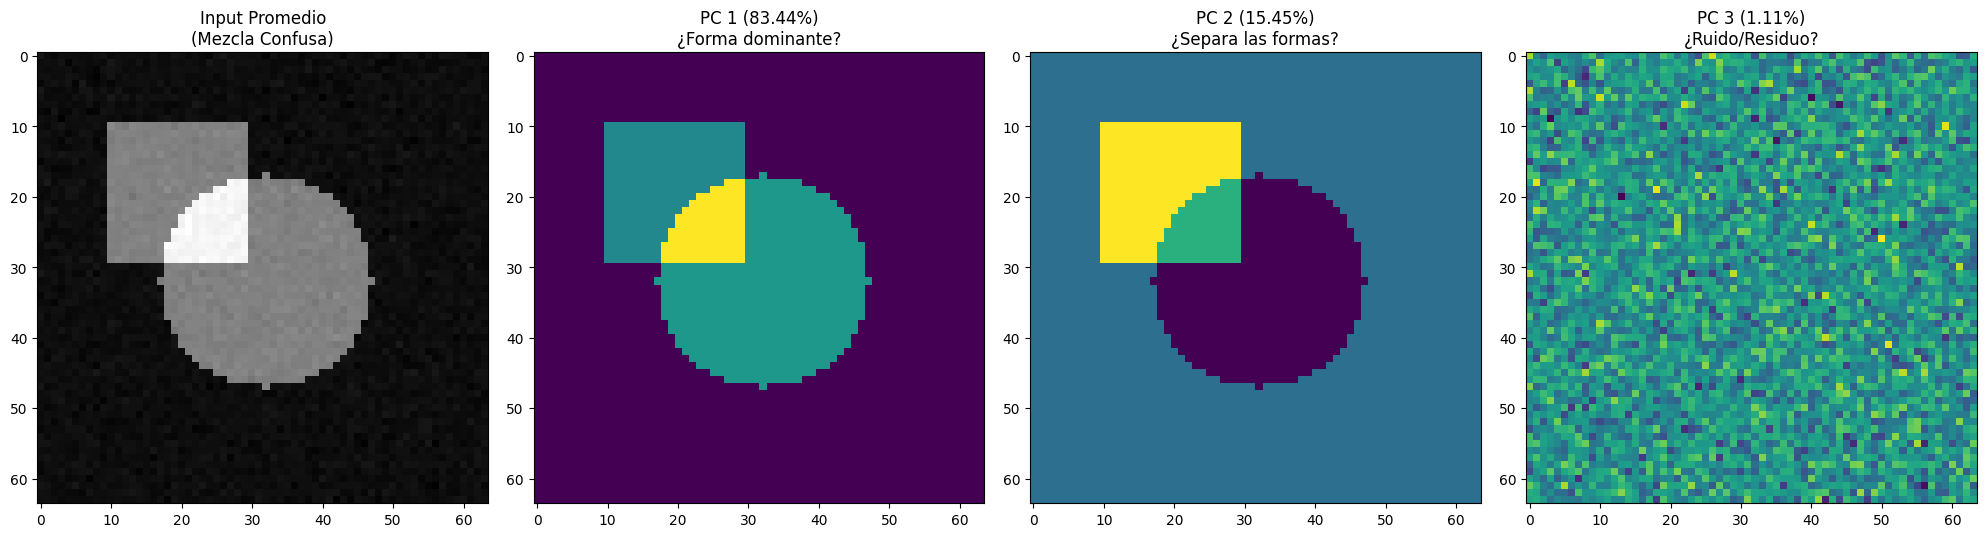

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# Asumiendo que importas tu clase PCAExtractor
from hyppo.extractor import PCAExtractor
from hyppo.core import HSI

# --- MOCK HSI ---
class HSI_Mock:
    def __init__(self, reflectance):
        self.reflectance = reflectance

def test_pca_dimensionality():
    print("🔵 TEST 1: Dimensiones y Manejo de Errores...")
    h, w, b = 20, 20, 10
    data = np.random.rand(h, w, b)
    hsi = HSI_Mock(data)
    
    # Caso 1: Pedir menos componentes que bandas (Normal)
    n_req = 3
    extractor = PCAExtractor(n_components=n_req)
    res = extractor.extract(hsi)
    feat = res['features']
    print(f"   Request: {n_req}, Output: {feat.shape}")
    if feat.shape == (h, w, n_req):
        print("   ✅ Reducción correcta.")
    else:
        print("   ❌ Fallo en dimensiones.")

    # Caso 2: Pedir MÁS componentes que bandas (Edge case)
    # Tu código tiene una protección: actual_n_components = min(...)
    n_req_excess = 50
    extractor = PCAExtractor(n_components=n_req_excess)
    res = extractor.extract(hsi)
    feat = res['features']
    expected = min(h*w, b) # En este caso limitado por bandas (10)
    print(f"   Request: {n_req_excess}, Output: {feat.shape}, Expected last dim: {expected}")
    
    if feat.shape[-1] == expected:
        print("   ✅ Manejo de n_components > n_bandas correcto.")
    else:
        print("   ❌ El código no limitó los componentes correctamente.")

def test_pca_redundancy():
    print("\n🔵 TEST 2: Física - Colapso de Redundancia (Rango 1)...")
    
    # Creamos un cubo donde TODAS las bandas son múltiplos de la Banda 0.
    # Matemáticamente, esto tiene Rango 1. 
    # El PCA debería decir que 1 solo componente explica el 100% de la varianza.
    h, w = 50, 50
    b = 5
    cube = np.zeros((h, w, b))
    
    # Señal base: Un degradado diagonal
    x = np.linspace(0, 1, w)
    y = np.linspace(0, 1, h)
    X, Y = np.meshgrid(x, y)
    signal = X + Y
    
    # Rellenar bandas con redundancia perfecta
    for i in range(b):
        cube[:, :, i] = signal * (i + 1) # Banda i es (i+1) veces la señal
        
    hsi = HSI_Mock(cube)
    
    # Extraemos 5 componentes
    extractor = PCAExtractor(n_components=5)
    res = extractor.extract(hsi)
    
    explained_var = res['explained_variance_ratio']
    print(f"   Varianza explicada por componente: {explained_var}")
    
    # Validación
    if explained_var[0] > 0.999:
        print("   ✅ ÉXITO: El PC1 captura >99.9% de la información (correcto para datos redundantes).")
        print("   ✅ Los otros componentes son ruido numérico (~0).")
    else:
        print("   ❌ FALLO: El PCA no detectó la redundancia lineal.")

def test_pca_visual_separation():
    print("\n🔵 TEST 3: Separación Visual de Fuentes...")
    
    h, w, b = 64, 64, 4
    cube = np.zeros((h, w, b))
    
    # --- FUENTE 1: Círculo en el centro ---
    Y, X = np.ogrid[:h, :w]
    dist_center = np.sqrt((X - w//2)**2 + (Y - h//2)**2)
    mask_circle = dist_center <= 15
    source1 = np.zeros((h, w))
    source1[mask_circle] = 1.0
    
    # --- FUENTE 2: Cuadrado en la esquina ---
    source2 = np.zeros((h, w))
    source2[10:30, 10:30] = 1.0
    
    # --- MEZCLA LINEAL EN LAS BANDAS ---
    # Simulamos que el sensor capta mezclas de estos "materiales"
    # Banda 0: Mucho círculo, poco cuadrado
    cube[:, :, 0] = 0.8 * source1 + 0.2 * source2
    # Banda 1: Poco círculo, mucho cuadrado
    cube[:, :, 1] = 0.2 * source1 + 0.8 * source2
    # Banda 2: Mezcla 50/50
    cube[:, :, 2] = 0.5 * source1 + 0.5 * source2
    # Banda 3: Ruido aleatorio suave
    cube[:, :, 3] = np.random.normal(0, 0.05, (h, w))
    
    hsi = HSI_Mock(cube)
    
    # Extraemos 3 PCs
    extractor = PCAExtractor(n_components=3)
    res = extractor.extract(hsi)
    feats = res['features']
    
    # Graficamos los Componentes Principales (Eigenimages)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Input promedio para referencia
    axes[0].imshow(np.mean(cube, axis=2), cmap='gray')
    axes[0].set_title("Input Promedio\n(Mezcla Confusa)")
    
    # PC1 (Debería ser una combinación fuerte de ambos o la forma dominante)
    axes[1].imshow(feats[:, :, 0], cmap='viridis')
    axes[1].set_title(f"PC 1 ({res['explained_variance_ratio'][0]:.2%})\n¿Forma dominante?")
    
    # PC2 (Debería capturar la diferencia, separando el cuadrado del círculo)
    axes[2].imshow(feats[:, :, 1], cmap='viridis')
    axes[2].set_title(f"PC 2 ({res['explained_variance_ratio'][1]:.2%})\n¿Separa las formas?")
    
    # PC3 (Debería ser mayormente ruido)
    axes[3].imshow(feats[:, :, 2], cmap='viridis')
    axes[3].set_title(f"PC 3 ({res['explained_variance_ratio'][2]:.2%})\n¿Ruido/Residuo?")
    
    plt.tight_layout()
    plt.show()

# --- EJECUTAR ---
test_pca_dimensionality()
test_pca_redundancy()
test_pca_visual_separation()

### mnf

🔵 TEST MNF: MNF vs PCA en Ambiente Ruidoso...
   Ejecutando PCA estándar...
   Ejecutando MNFExtractor...
SNR estimates: [7.26773131e+00 3.71156175e-02 2.25404547e-02 1.40988940e-02
 7.87555748e-03 4.60399487e-03 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


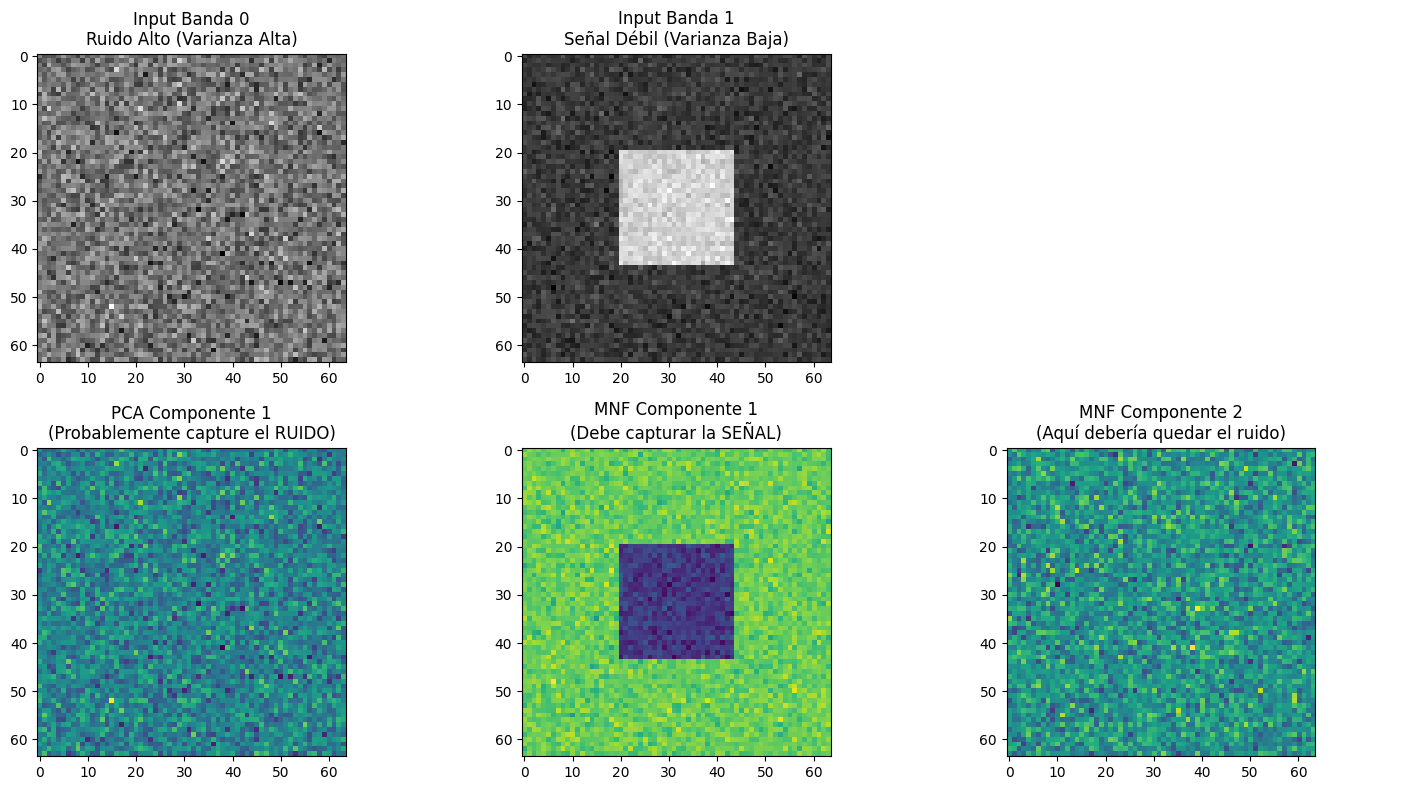


   PCA Explained Variance Ratio (PC1): 0.9272
   (PCA cree que ha hecho un gran trabajo explicando el ruido)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SklearnPCA
# Asumiendo que importas tu clase MNFExtractor
from hyppo.extractor import MNFExtractor

# --- MOCK HSI ---
class HSI_Mock:
    def __init__(self, reflectance):
        self.reflectance = reflectance

def test_mnf_vs_pca_noise_handling():
    print("🔵 TEST MNF: MNF vs PCA en Ambiente Ruidoso...")
    
    H, W = 64, 64
    B = 10
    cube = np.zeros((H, W, B))
    
    # --- ESCENARIO TRAMPA ---
    
    # BANDA 0: RUIDO PURO pero de ALTA AMPLITUD (Varianza enorme)
    # PCA verá esto y dirá: "¡Mucha información! Esto es PC1".
    # MNF verá esto, calculará diferencias vecinas altas y dirá: "Es solo ruido".
    noise_high_var = np.random.normal(0, 10.0, (H, W)) # Sigma=10
    cube[:, :, 0] = noise_high_var
    
    # BANDA 1: SEÑAL LIMPIA pero de BAJA AMPLITUD (Varianza pequeña)
    # Un cuadrado simple.
    # PCA despreciará esto porque su varianza es baja comparada con la Banda 0.
    # MNF debería rescatar esto como la Componente 1 (mejor SNR).
    signal = np.zeros((H, W))
    signal[20:44, 20:44] = 1.0 # Señal binaria 0/1 (Varianza baja)
    # Le añadimos un poquitín de ruido para que no sea singular
    signal += np.random.normal(0, 0.1, (H, W)) 
    cube[:, :, 1] = signal
    
    # BANDAS 2-9: Ruido de relleno (Baja varianza)
    for i in range(2, B):
        cube[:, :, i] = np.random.normal(0, 1.0, (H, W))
        
    hsi = HSI_Mock(cube)
    
    # --- 1. EJECUTAR PCA (El control) ---
    # Usamos sklearn directo para simular un PCA estándar
    print("   Ejecutando PCA estándar...")
    X_flat = cube.reshape(-1, B)
    pca = SklearnPCA(n_components=2)
    pca_feats = pca.fit_transform(X_flat).reshape(H, W, 2)
    
    # --- 2. EJECUTAR MNF (Tu extractor) ---
    print("   Ejecutando MNFExtractor...")
    mnf_extractor = MNFExtractor(n_components=10)
    res_mnf = mnf_extractor.extract(hsi)
    mnf_feats = res_mnf['features']

    print("SNR estimates:", res_mnf["snr_estimates"])

    
    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Fila 1: Inputs
    axes[0, 0].imshow(cube[:, :, 0], cmap='gray')
    axes[0, 0].set_title("Input Banda 0\nRuido Alto (Varianza Alta)")
    
    axes[0, 1].imshow(cube[:, :, 1], cmap='gray')
    axes[0, 1].set_title("Input Banda 1\nSeñal Débil (Varianza Baja)")
    
    axes[0, 2].axis('off') # Espacio vacío
    
    # Fila 2: Resultados
    # PCA Componente 1
    axes[1, 0].imshow(pca_feats[:, :, 0], cmap='viridis')
    axes[1, 0].set_title("PCA Componente 1\n(Probablemente capture el RUIDO)")
    
    # MNF Componente 1
    axes[1, 1].imshow(mnf_feats[:, :, 0], cmap='viridis')
    axes[1, 1].set_title("MNF Componente 1\n(Debe capturar la SEÑAL)")
    
    # MNF Componente 2 (o último)
    # En MNF, el ruido se empuja al final. Veamos si la comp 2 se parece al ruido.
    axes[1, 2].imshow(mnf_feats[:, :, 1], cmap='viridis')
    axes[1, 2].set_title("MNF Componente 2\n(Aquí debería quedar el ruido)")
    
    plt.tight_layout()
    plt.show()
    
    # Validación Numérica (Varianza explicada vs Calidad)
    # En PCA, la varanza explicada de PC1 será enorme (dominada por el ruido).
    print(f"\n   PCA Explained Variance Ratio (PC1): {pca.explained_variance_ratio_[0]:.4f}")
    print(f"   (PCA cree que ha hecho un gran trabajo explicando el ruido)")

test_mnf_vs_pca_noise_handling()

In [2]:
def test_mnf_snr_ordering():
    np.random.seed(0)

    H, W, B = 50, 50, 20
    noise = np.random.normal(0, 1.0, (H, W, B))
    signal = np.zeros_like(noise)
    signal[20:30, 20:30, :] = 3.0

    hsi = HSI_Mock(noise + signal)

    mnf = MNFExtractor(n_components=3)
    res = mnf.extract(hsi)

    snr = res["snr_eigenvalues"]
    assert snr[0] > snr[-1], "MNF did not order components by SNR"


In [4]:
test_mnf_snr_ordering()

### ica


🔵 TEST ICA: Separación Ciega de Fuentes (Cocktail Party)...
   Ejecutando ICAExtractor (n=3)...
   Ejecutando PCA (Control)...


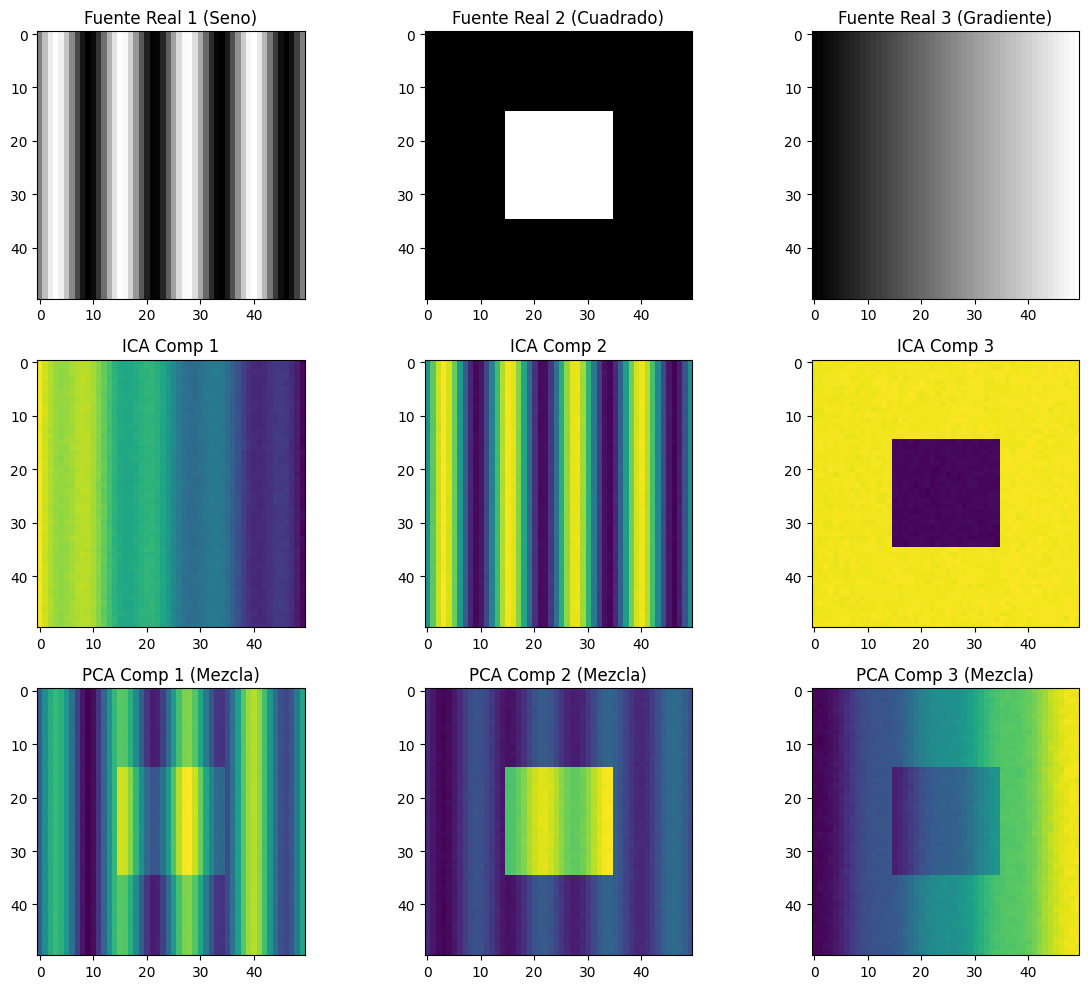


   Error de reconstrucción (MSE): 0.000010
   ✅ ÉXITO: Reconstrucción precisa.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from hyppo.extractor import ICAExtractor  # Importa tu clase real aquí

# --- MOCK HSI ---
class HSI_Mock:
    def __init__(self, reflectance):
        self.reflectance = reflectance

def test_ica_blind_source_separation():
    print("🔵 TEST ICA: Separación Ciega de Fuentes (Cocktail Party)...")
    
    H, W = 50, 50
    
    # 1. GENERAR FUENTES PURAS (Latentes)
    # Fuente 1: Senoidal (Ondas verticales)
    x = np.linspace(0, 8*np.pi, W)
    S1 = np.sin(x).reshape(1, W)
    S1 = np.tile(S1, (H, 1)) 
    
    # Fuente 2: Señal Cuadrada (Bloque central)
    S2 = np.zeros((H, W))
    S2[15:35, 15:35] = 1.0 
    
    # Fuente 3: Gradiente lineal
    S3_row = np.linspace(0, 1, W)
    S3 = np.tile(S3_row, (H, 1))
    
    # Matriz de fuentes (3 x N_pixels)
    S = np.c_[S1.ravel(), S2.ravel(), S3.ravel()].T 
    
    # 2. MEZCLAR FUENTES
    # Matriz de mezcla aleatoria (Simula cómo el sensor capta combinaciones)
    np.random.seed(42)
    A = np.array([
        [0.5, 0.5, 0.1],  # Banda 0
        [0.2, 0.8, 0.2],  # Banda 1
        [0.9, 0.1, 0.5],  # ...
        [0.3, 0.3, 0.9],
        [0.6, 0.2, 0.6]
    ]) # (5 bandas, 3 fuentes)
    
    # Aplicar mezcla
    X_flat = np.dot(A, S) 
    # Formar cubo HSI (H, W, 5)
    cube = X_flat.T.reshape(H, W, 5)
    # Añadir ruido leve
    cube += 0.005 * np.random.normal(size=cube.shape)
    
    hsi = HSI_Mock(cube)
    
    # 3. EJECUTAR ICA (Tu extractor)
    print("   Ejecutando ICAExtractor (n=3)...")
    # Nota: ICA tiene ambigüedad de signo y orden.
    ica_ext = ICAExtractor(n_components=3, random_state=42)
    res_ica = ica_ext.extract(hsi)
    feats_ica = res_ica['features']
    
    # 4. EJECUTAR PCA (Control)
    print("   Ejecutando PCA (Control)...")
    pca = PCA(n_components=3)
    feats_pca = pca.fit_transform(cube.reshape(-1, 5)).reshape(H, W, 3)
    
    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    
    # Fila 1: Fuentes Reales
    axes[0, 0].imshow(S1, cmap='gray'); axes[0, 0].set_title("Fuente Real 1 (Seno)")
    axes[0, 1].imshow(S2, cmap='gray'); axes[0, 1].set_title("Fuente Real 2 (Cuadrado)")
    axes[0, 2].imshow(S3, cmap='gray'); axes[0, 2].set_title("Fuente Real 3 (Gradiente)")
    
    # Fila 2: Resultados ICA (Deberían ser idénticos a los reales, quizás invertidos/desordenados)
    axes[1, 0].imshow(feats_ica[:, :, 0], cmap='viridis'); axes[1, 0].set_title("ICA Comp 1")
    axes[1, 1].imshow(feats_ica[:, :, 1], cmap='viridis'); axes[1, 1].set_title("ICA Comp 2")
    axes[1, 2].imshow(feats_ica[:, :, 2], cmap='viridis'); axes[1, 2].set_title("ICA Comp 3")
    
    # Fila 3: Resultados PCA (Deberían verse mezclados)
    axes[2, 0].imshow(feats_pca[:, :, 0], cmap='viridis'); axes[2, 0].set_title("PCA Comp 1 (Mezcla)")
    axes[2, 1].imshow(feats_pca[:, :, 1], cmap='viridis'); axes[2, 1].set_title("PCA Comp 2 (Mezcla)")
    axes[2, 2].imshow(feats_pca[:, :, 2], cmap='viridis'); axes[2, 2].set_title("PCA Comp 3 (Mezcla)")
    
    plt.tight_layout()
    plt.show()

    # Validación de Error
    rec_error = res_ica['reconstruction_error']
    print(f"\n   Error de reconstrucción (MSE): {rec_error:.6f}")
    if rec_error is not None and rec_error < 0.01:
        print("   ✅ ÉXITO: Reconstrucción precisa.")
    else:
        print("   ⚠️ ADVERTENCIA: Error de reconstrucción alto.")

test_ica_blind_source_separation()

### pp

🔵 TEST FINAL PP: Verificación con Rango Dinámico...
   Divergence Scores: ['0.18', '0.08', '0.08']
   PCA explained variance: ['0.072', '0.057', '0.054']
   ❌ FALLO: La divergencia sigue siendo baja.


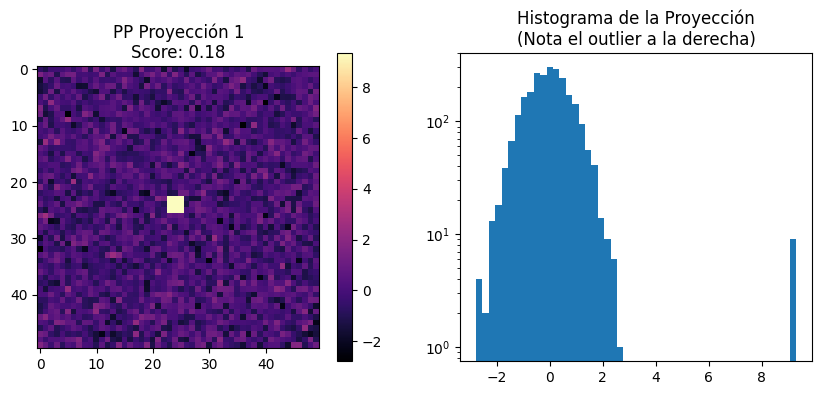

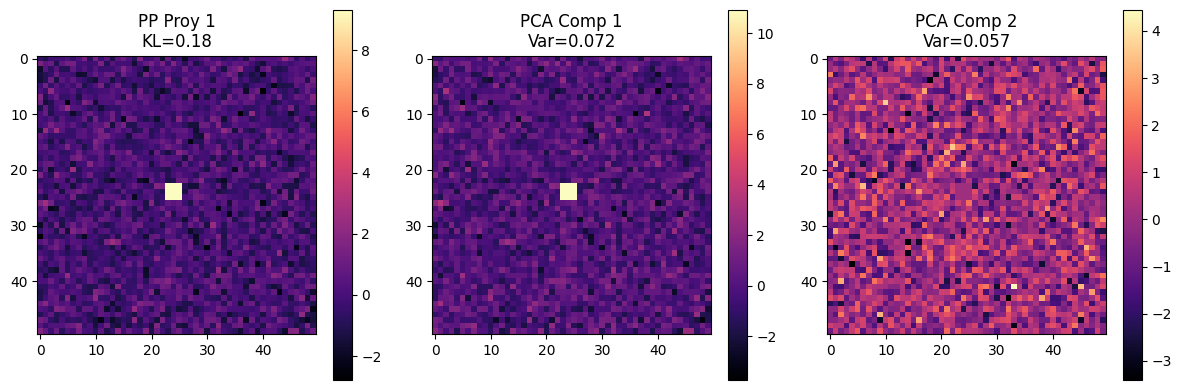

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# Asumiendo que importas tu clase PPExtractor
from hyppo.extractor import PPExtractor

# --- MOCK HSI ---
class HSI_Mock:
    def __init__(self, reflectance):
        self.reflectance = reflectance

def run_pca_baseline(hsi, n_components=3):
    X = hsi.reflectance
    H, W, B = X.shape
    Xf = X.reshape(-1, B)

    pca = PCA(n_components=n_components)
    Xp = pca.fit_transform(Xf)

    feats_pca = Xp.reshape(H, W, n_components)
    return feats_pca, pca.explained_variance_ratio_


def test_pp_final_verification():
    print("🔵 TEST FINAL PP: Verificación con Rango Dinámico...")
    
    H, W = 50, 50
    B = 20
    
    # 1. Fondo Ruidoso (Normal)
    np.random.seed(42)
    background = np.random.normal(0, 1.0, (H, W, B))
    
    # 2. Objetivo Fuerte ("Outlier" claro)
    # Valor 10 vs Ruido 1 -> Es una anomalía masiva.
    target_signature = np.ones(B) * 2.5
    
    cube = background.copy()
    cube[23:26, 23:26, :] = target_signature
    
    hsi = HSI_Mock(cube)
    
    # --- EJECUCIÓN ---
    # Usamos sample_size grande para asegurar que revisa el píxel central
    pp_ext = PPExtractor(
        n_projections=3, 
        n_bins=50, 
        sample_size=H*W, 
        random_state=42
    )
    
    res_pp = pp_ext.extract(hsi)
    feats = res_pp['features']
    scores = res_pp['divergence_scores']
    
    print(f"   Divergence Scores: {[f'{s:.2f}' for s in scores]}")

    # --- PCA BASELINE ---
    feats_pca, var_ratio = run_pca_baseline(hsi, n_components=3)

    print(f"   PCA explained variance: {[f'{v:.3f}' for v in var_ratio]}")

    
    # Validación Automática
    if float(scores[0]) > 1.0:
        print("   ✅ ÉXITO: Divergencia alta detectada. El rango dinámico funcionó.")
    else:
        print("   ❌ FALLO: La divergencia sigue siendo baja.")

    # Visualización
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(feats[:, :, 0], cmap='magma')
    plt.title(f"PP Proyección 1\nScore: {scores[0]:.2f}")
    plt.colorbar()
    
    plt.subplot(1, 2, 2)
    plt.hist(feats[:, :, 0].ravel(), bins=50, log=True)
    plt.title("Histograma de la Proyección\n(Nota el outlier a la derecha)")
    plt.show()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(feats[:, :, 0], cmap='magma')
    plt.title(f"PP Proy 1\nKL={scores[0]:.2f}")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(feats_pca[:, :, 0], cmap='magma')
    plt.title(f"PCA Comp 1\nVar={var_ratio[0]:.3f}")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(feats_pca[:, :, 1], cmap='magma')
    plt.title(f"PCA Comp 2\nVar={var_ratio[1]:.3f}")
    plt.colorbar()

    plt.tight_layout()
    plt.show()


# Ejecutar test corregido
test_pp_final_verification()

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_pp_result(hsi, res, title_prefix="PP"):
    feats = res["features"]
    kl = res["divergence_scores"]
    n_proj = feats.shape[-1]

    fig, axes = plt.subplots(
        n_proj, 2, figsize=(8, 3 * n_proj),
        gridspec_kw={"width_ratios": [1, 1.2]}
    )

    if n_proj == 1:
        axes = np.array([axes])

    for i in range(n_proj):
        # --- Spatial map ---
        ax = axes[i, 0]
        im = ax.imshow(feats[:, :, i], cmap="magma")
        ax.set_title(f"{title_prefix} Proy {i+1}\nKL={kl[i]:.2f}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

        # --- Histogram ---
        ax = axes[i, 1]
        ax.hist(feats[:, :, i].ravel(), bins=50, density=True)
        ax.set_yscale("log")
        ax.set_title("Score distribution (log)")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [21]:
def test_pp_detects_global_nongaussianity():
    np.random.seed(0)

    H, W = 50, 50
    B = 20

    background = np.random.normal(0, 1.0, (H, W, B))
    target_signature = np.ones(B) * 8.0

    cube = background.copy()
    cube[23:26, 23:26, :] = target_signature

    hsi = HSI_Mock(cube)

    pp = PPExtractor(
        n_projections=3,
        n_bins=50,
        sample_size=H * W,
        random_state=0,
    )

    res = pp.extract(hsi)
    kl = np.array(res["divergence_scores"])

    # 1️⃣ Primera proyección claramente no-gaussiana
    assert kl[0] > 1.0, (
        f"First PP projection should be strongly non-Gaussian, got KL={kl[0]:.3f}"
    )

    # 2️⃣ El resto NO debe ser informativo
    assert np.max(kl[1:]) < 0.5, (
        f"Higher-order projections should be near-Gaussian, got {kl[1:]}"
    )

    # 3️⃣ Separación clara
    assert kl[0] > 3 * np.max(kl[1:]), (
        "First projection not clearly dominant"
    )

    # 4️⃣ Ortogonalidad (opcional, pero buena)
    V = res["projection_vectors"]
    G = V @ V.T
    off_diag = G - np.eye(len(V))
    assert np.max(np.abs(off_diag)) < 1e-6
    visualize_pp_result(hsi, res, title_prefix="PP")



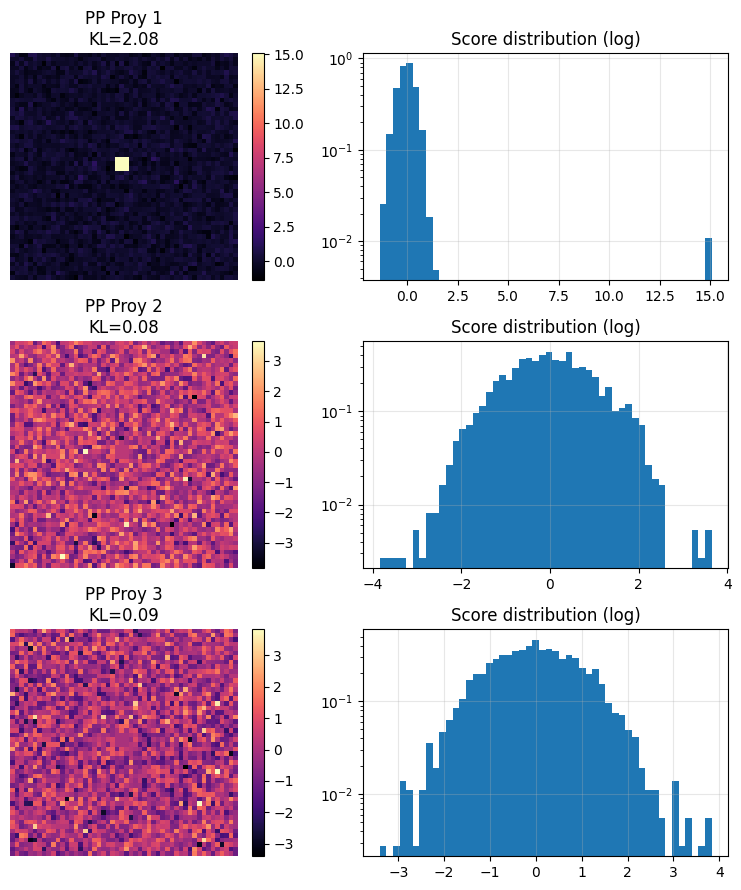

In [22]:
test_pp_detects_global_nongaussianity()

In [19]:
def test_pp_on_pure_gaussian_noise():
    """
    PP should not find strong projections in purely Gaussian data.
    """

    np.random.seed(1)

    H, W, B = 40, 40, 15
    cube = np.random.normal(0, 1.0, (H, W, B))
    hsi = HSI_Mock(cube)

    pp = PPExtractor(n_projections=2, sample_size=H * W)
    res = pp.extract(hsi)

    kl = np.array(res["divergence_scores"])

    assert kl[0] < 0.3, "PP falsely detected non-Gaussianity in pure noise"
    visualize_pp_result(hsi, res, title_prefix="PP (Gaussian)")


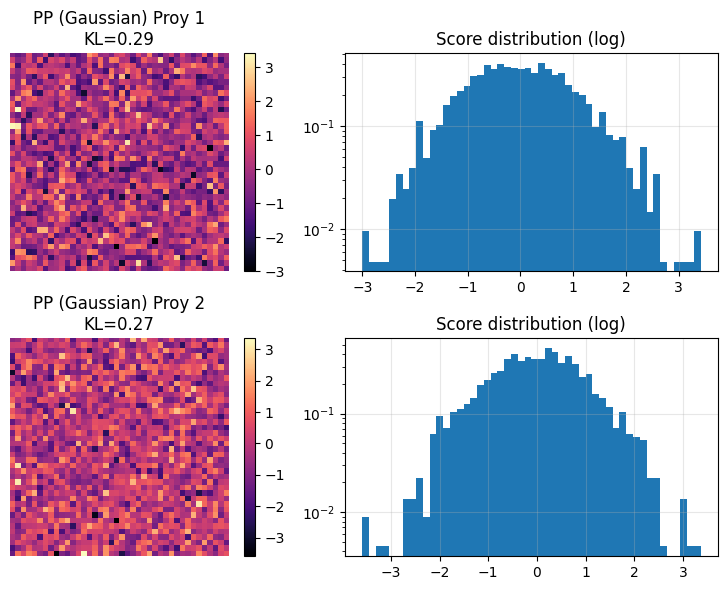

In [20]:
test_pp_on_pure_gaussian_noise()

🔵 COMPARACIÓN CALIBRADA: PCA vs. PP...
   Ejecutando PCA...
   Ejecutando PPExtractor...
   Scores PP: ['0.09', '0.06', '0.06']


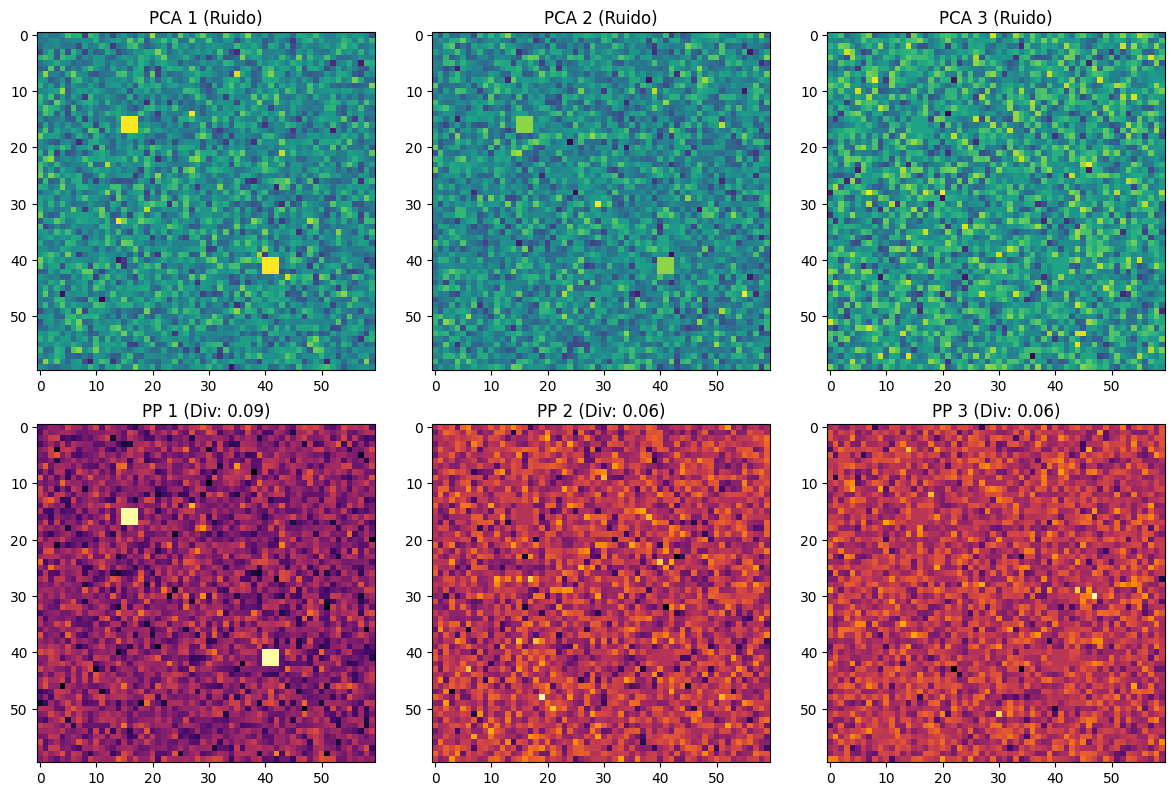

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from hyppo.extractor import PPExtractor

class HSI_Mock:
    def __init__(self, reflectance):
        self.reflectance = reflectance

def compare_pca_vs_pp_calibrated():
    print("🔵 COMPARACIÓN CALIBRADA: PCA vs. PP...")
    
    H, W = 60, 60
    B = 30
    
    # 1. FONDO (Ruido fuerte)
    # Sigma = 2.0. Varianza = 4.0.
    np.random.seed(42)
    background = np.random.normal(0, 2.0, (H, W, B))
    
    # 2. OBJETIVO (El "Punto Dulce")
    # Amplitud 2.0. 
    # Es igual al ruido (SNR = 1 per band). 
    # PCA no puede verlo porque no aumenta la varianza global significativamente.
    # PP sí puede verlo porque al sumar 30 bandas, el Z-score sube a >5.0.
    target_signature = np.ones(B) * 2.0
    
    cube = background.copy()
    cube[15:18, 15:18, :] = target_signature # Objetivo 1
    cube[40:43, 40:43, :] = target_signature # Objetivo 2
    
    hsi = HSI_Mock(cube)
    
    # --- EJECUCIÓN ---
    
    # A. PCA
    print("   Ejecutando PCA...")
    pca = PCA(n_components=3)
    feats_pca = pca.fit_transform(cube.reshape(-1, B)).reshape(H, W, 3)
    
    # B. PP (Usando tu clase corregida)
    print("   Ejecutando PPExtractor...")
    pp_ext = PPExtractor(
        n_projections=3, 
        n_bins=60, 
        sample_size=H*W, # Fuerza bruta
        random_state=42
    )
    
    res_pp = pp_ext.extract(hsi)
    feats_pp = res_pp['features']
    scores = res_pp['divergence_scores']
    
    print(f"   Scores PP: {[f'{s:.2f}' for s in scores]}")

    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    
    # PCA (Debería ser ruido)
    axes[0, 0].imshow(feats_pca[:, :, 0], cmap='viridis'); axes[0, 0].set_title("PCA 1 (Ruido)")
    axes[0, 1].imshow(feats_pca[:, :, 1], cmap='viridis'); axes[0, 1].set_title("PCA 2 (Ruido)")
    axes[0, 2].imshow(feats_pca[:, :, 2], cmap='viridis'); axes[0, 2].set_title("PCA 3 (Ruido)")
    
    # PP (Debería ver los cuadrados)
    # Nota: Puede que salgan oscuros o claros, importa el contraste.
    axes[1, 0].imshow(feats_pp[:, :, 0], cmap='inferno'); axes[1, 0].set_title(f"PP 1 (Div: {scores[0]:.2f})")
    axes[1, 1].imshow(feats_pp[:, :, 1], cmap='inferno'); axes[1, 1].set_title(f"PP 2 (Div: {scores[1]:.2f})")
    axes[1, 2].imshow(feats_pp[:, :, 2], cmap='inferno'); axes[1, 2].set_title(f"PP 3 (Div: {scores[2]:.2f})")
    
    plt.tight_layout()
    plt.show()

compare_pca_vs_pp_calibrated()

🔵 COMPARACIÓN ESTRATÉGICA: Fondo Estructurado...
   Estrategia: Distraer a PCA con un gradiente fuerte.
   Ejecutando PCA...
   PCA Varianza: PC1=97.1% (Debería ser el gradiente)
   Ejecutando PPExtractor...
   PP Scores: ['0.68', '0.07', '0.07']


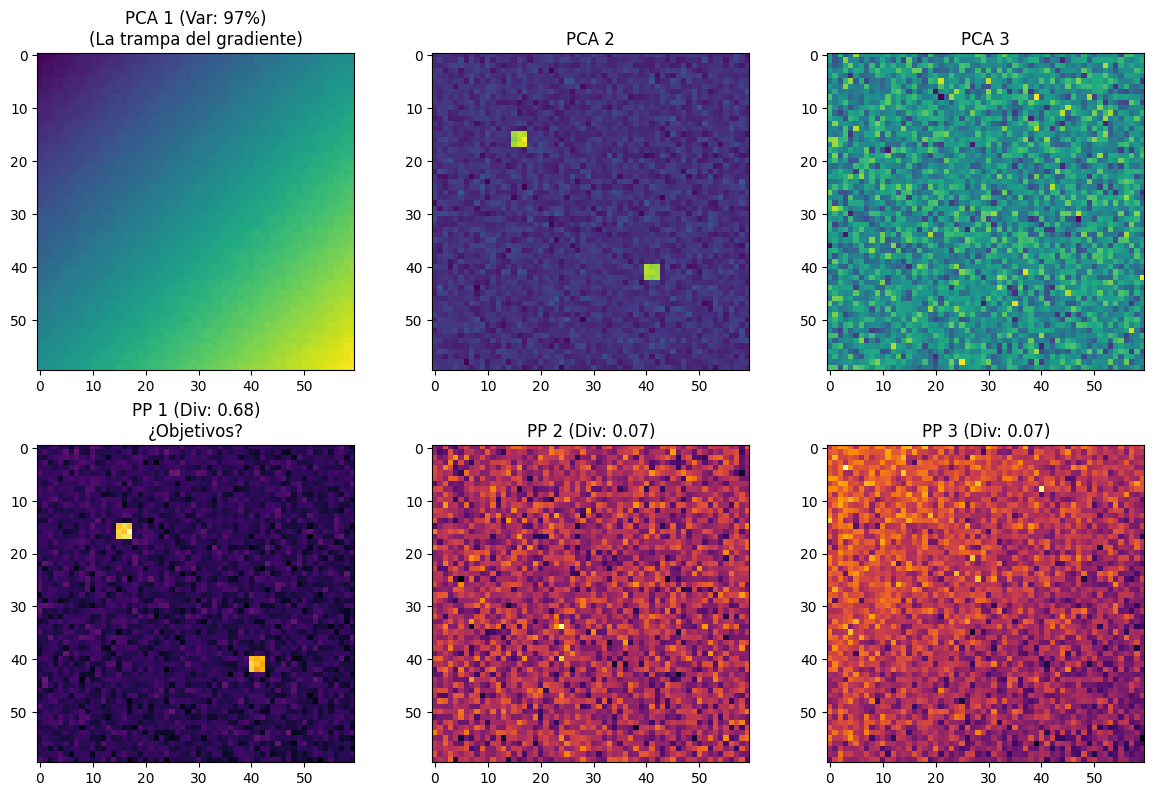

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# from hyppo.extractor import PPExtractor

class HSI_Mock:
    def __init__(self, reflectance):
        self.reflectance = reflectance

def compare_pca_vs_pp_structured():
    print("🔵 COMPARACIÓN ESTRATÉGICA: Fondo Estructurado...")
    print("   Estrategia: Distraer a PCA con un gradiente fuerte.")
    
    H, W = 60, 60
    B = 40
    
    # 1. RUIDO BASE (Bajo)
    np.random.seed(42)
    cube = np.random.normal(0, 0.5, (H, W, B))
    
    # 2. INTERFERENCIA ("CLUTTER")
    # Un gradiente diagonal fuerte que afecta a las primeras 20 bandas.
    # Esto genera ENORME varianza. PCA dedicará el PC1 a explicar esto.
    x = np.linspace(0, 1, W)
    y = np.linspace(0, 1, H)
    X, Y = np.meshgrid(x, y)
    gradient = 10.0 * (X + Y) # Amplitud 10 (Gigante comparado con todo)
    
    for b in range(20): # Bandas 0 a 19 contaminadas
        cube[:, :, b] += gradient
        
    # 3. OBJETIVO ("LA AGUJA")
    # Un objetivo pequeño, constante, solo en las bandas 20-40.
    # Amplitud 2.0 (Pequeña comparada con el gradiente de 10.0).
    target_sig = np.zeros(B)
    target_sig[20:] = 2.0 
    
    # Insertar objetivos
    cube[15:18, 15:18, :] += target_sig
    cube[40:43, 40:43, :] += target_sig
    
    hsi = HSI_Mock(cube)
    
    # --- EJECUCIÓN ---
    
    # A. PCA
    print("   Ejecutando PCA...")
    pca = PCA(n_components=3)
    feats_pca = pca.fit_transform(cube.reshape(-1, B)).reshape(H, W, 3)
    var = pca.explained_variance_ratio_
    print(f"   PCA Varianza: PC1={var[0]:.1%} (Debería ser el gradiente)")
    
    # B. PP
    print("   Ejecutando PPExtractor...")
    pp_ext = PPExtractor(
        n_projections=3, 
        n_bins=60, 
        sample_size=H*W, 
        random_state=42
    )
    
    res_pp = pp_ext.extract(hsi)
    feats_pp = res_pp['features']
    scores = res_pp['divergence_scores']
    print(f"   PP Scores: {[f'{s:.2f}' for s in scores]}")

    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    
    # PCA
    axes[0, 0].imshow(feats_pca[:, :, 0], cmap='viridis')
    axes[0, 0].set_title(f"PCA 1 (Var: {var[0]:.0%})\n(La trampa del gradiente)")
    axes[0, 1].imshow(feats_pca[:, :, 1], cmap='viridis')
    axes[0, 1].set_title("PCA 2")
    axes[0, 2].imshow(feats_pca[:, :, 2], cmap='viridis')
    axes[0, 2].set_title("PCA 3")
    
    # PP
    # Debería ignorar el gradiente (porque es una distribución 'plana' común)
    # y encontrar los puntos (que son anomalías estadísticas).
    axes[1, 0].imshow(feats_pp[:, :, 0], cmap='inferno')
    axes[1, 0].set_title(f"PP 1 (Div: {scores[0]:.2f})\n¿Objetivos?")
    axes[1, 1].imshow(feats_pp[:, :, 1], cmap='inferno')
    axes[1, 1].set_title(f"PP 2 (Div: {scores[1]:.2f})")
    axes[1, 2].imshow(feats_pp[:, :, 2], cmap='inferno')
    axes[1, 2].set_title(f"PP 3 (Div: {scores[2]:.2f})")
    
    plt.tight_layout()
    plt.show()

compare_pca_vs_pp_structured()

### geometrico

In [1]:
import hyppo
from hyppo.core import FeatureSpace
from hyppo.extractor import GeometricMomentExtractor

# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    GeometricMomentExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
print(results.get_all_features())
print(results.describe())

{'features': array([[[-6.78237700e+00,  0.00000000e+00, -2.71011877e+00, ...,
         -2.74438675e-17, -3.09133144e-17,  2.30427339e+00],
        [-6.50705934e+00,  0.00000000e+00, -2.80527782e+00, ...,
          1.98821909e-01,  2.70779493e-17,  2.27749733e+00],
        [-6.36192346e+00,  0.00000000e+00, -3.69502974e+00, ...,
          7.56719107e-01,  4.72915435e-17,  2.15526957e+00],
        ...,
        [ 2.19281006e+00,  0.00000000e+00,  1.66288614e+00, ...,
          1.82414807e+00,  1.88786703e-17,  1.03756276e+00],
        [ 2.26252508e+00,  0.00000000e+00,  1.63501787e+00, ...,
          2.28516956e+00, -1.04185053e-16,  7.86358204e-01],
        [ 2.86473536e+00,  0.00000000e+00,  1.84006071e+00, ...,
          2.33442280e-17, -1.82891354e-17,  8.70589890e-01]],

       [[-3.45198059e+00,  6.04759526e+00, -2.09692121e+00, ...,
         -3.92006848e-17,  2.43267862e-18,  2.49080294e+00],
        [-3.22160220e+00,  5.58459973e+00, -1.81896329e+00, ...,
          1.74078171e-01,

In [3]:
import pytest
import numpy as np
from hyppo.core import HSI
from hyppo.extractor import GeometricMomentExtractor

def test_geometric_moment_extractor_dimensions():
    """Verifica que las dimensiones de salida sean correctas."""
    # Crear HSI sintética (10x10 píxeles, 20 bandas)
    n_bands = 20
    data = np.random.rand(10, 10, n_bands).astype(np.float32)
    
    # Crear vector de wavelengths ficticio (requerido por HSI)
    wavelengths = np.linspace(400, 2500, n_bands) 
    
    # Instanciación corregida
    hsi = HSI(reflectance=data, wavelengths=wavelengths)
    
    n_pcs = 2
    order = 3
    windows = [3, 5]
    
    # Cálculo teórico de momentos por escala: (order + 1) * (order + 2) / 2
    moments_per_scale = (order + 1) * (order + 2) // 2
    total_expected_features = n_pcs * len(windows) * moments_per_scale
    
    extractor = GeometricMomentExtractor(
        n_components=n_pcs, 
        max_order=order, 
        window_sizes=windows
    )
    
    result = extractor.extract(hsi)
    features = result["features"]
    
    assert features.shape == (10, 10, total_expected_features)
    assert result["n_components"] == n_pcs


def test_geometric_moment_extractor_invalid_params():
    """Verifica que las validaciones de parámetros funcionen."""
    data = np.random.rand(10, 10, 5).astype(np.float32)
    # Crear vector de wavelengths ficticio (requerido por HSI)
    wavelengths = np.linspace(400, 2500, 5) 
    
    # Instanciación corregida
    hsi = HSI(reflectance=data, wavelengths=wavelengths)
    
    # Ventana par (debe fallar)
    with pytest.raises(ValueError, match="must be an odd integer"):
        ext = GeometricMomentExtractor(window_sizes=[2, 3])
        ext.extract(hsi)
        
    # Orden negativo
    with pytest.raises(ValueError, match="non-negative integer"):
        ext = GeometricMomentExtractor(max_order=-1)
        ext.extract(hsi)

In [4]:
test_geometric_moment_extractor_invalid_params()
test_geometric_moment_extractor_dimensions()

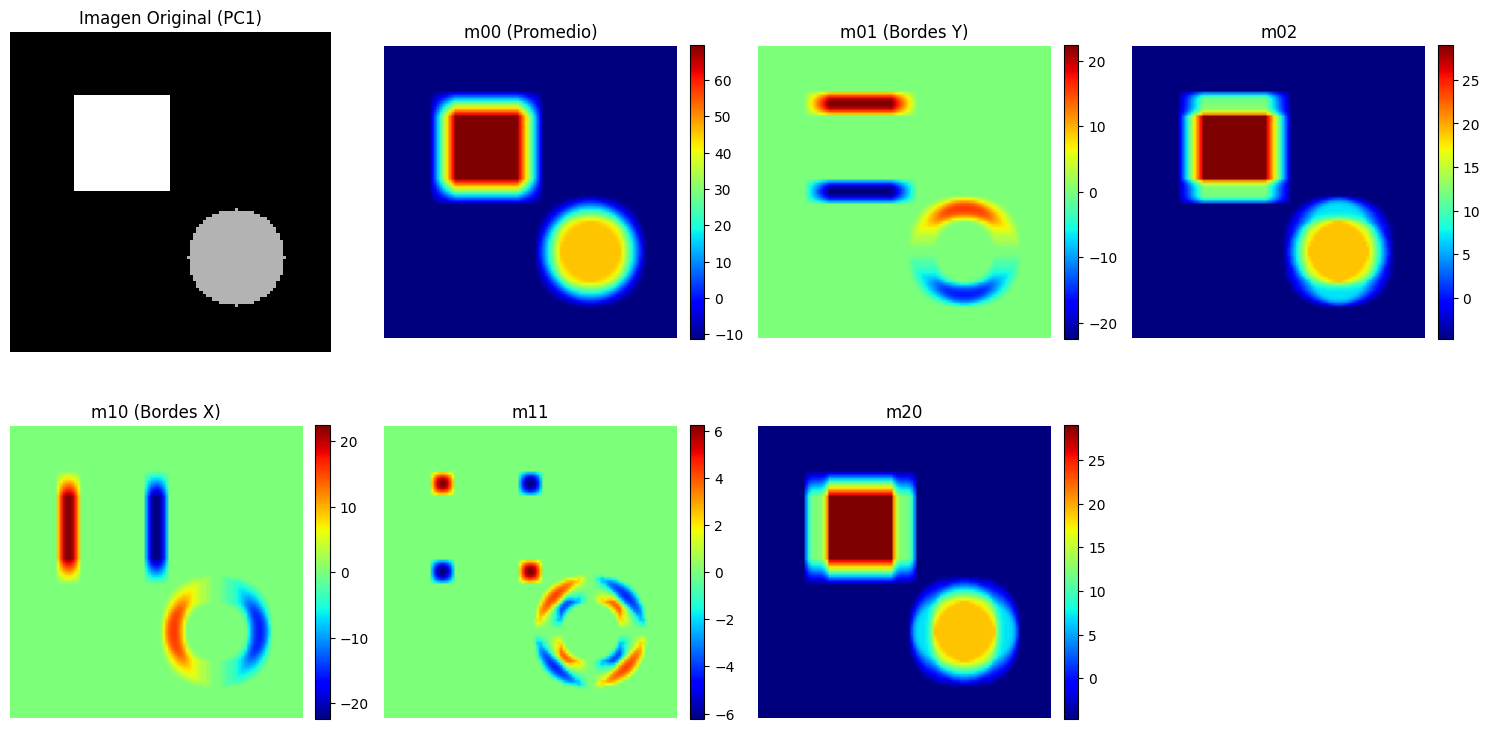

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from hyppo.core import HSI
from hyppo.extractor import GeometricMomentExtractor

def test_visualize_geometric_moments():
    """Genera una imagen sintética y visualiza los momentos extraídos."""
    # 1. Crear una imagen ficticia de 100x100 con formas geométricas
    # Esto simula un componente principal (PC) de una imagen HS [cite: 144]
    img = np.zeros((100, 100))
    img[20:50, 20:50] = 1.0  # Un cuadrado
    
    # Crear un círculo usando distancias
    yy, xx = np.ogrid[:100, :100]
    mask = (xx - 70)**2 + (yy - 70)**2 <= 15**2
    img[mask] = 0.7
    
    # Convertir a formato HSI (ficticio con 1 banda y lambda 1.0)
    # Expandimos a (H, W, 1)
    data = img[:, :, np.newaxis].astype(np.float32)
    wavelengths = np.array([1.0], dtype=np.float32)
    hsi = HSI(reflectance=data, wavelengths=wavelengths)
    
    # 2. Configurar el extractor
    # Usamos max_order=2 para ver los momentos básicos:
    # m00 (área/brillo), m10/m01 (centroides/bordes) [cite: 81, 93]
    extractor = GeometricMomentExtractor(
        n_components=1, 
        max_order=2, 
        window_sizes=[9]
    )
    
    result = extractor.extract(hsi)
    features = result["features"] # Dimensiones (100, 100, 6)
    
    # Nombres de los momentos para el orden 2: (0,0), (0,1), (0,2), (1,0), (1,1), (2,0)
    moment_names = ["m00 (Promedio)", "m01 (Bordes Y)", "m02", "m10 (Bordes X)", "m11", "m20"]
    
    # 3. Graficar los resultados
    plt.figure(figsize=(15, 8))
    
    # Mostrar imagen original
    plt.subplot(2, 4, 1)
    plt.title("Imagen Original (PC1)")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    # Mostrar los primeros 6 momentos extraídos
    for i in range(features.shape[-1]):
        plt.subplot(2, 4, i + 2)
        plt.title(moment_names[i])
        plt.imshow(features[:, :, i], cmap='jet')
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Ejecutar la prueba
if __name__ == "__main__":
    test_visualize_geometric_moments()

### legendre


In [1]:
import hyppo
from hyppo.core import FeatureSpace
from hyppo.extractor import LegendreMomentExtractor

# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    LegendreMomentExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
print(results.get_all_features())
print(results.describe())

{'features': array([[[-3.39118850e+00,  0.00000000e+00, -7.53543341e-01, ...,
         -6.67868538e-16, -2.60208521e-18,  3.27415068e+00],
        [-3.25352967e+00,  0.00000000e+00, -1.06703718e+00, ...,
          1.24790276e+00, -1.87350135e-16,  2.88630825e+00],
        [-3.18096173e+00, -4.16333634e-17, -2.64032992e+00, ...,
          2.34907383e+00, -1.73472348e-16,  1.63081043e+00],
        ...,
        [ 1.09640503e+00,  0.00000000e+00,  1.56292675e+00, ...,
         -9.41174082e-01,  9.36750677e-17,  2.31095030e+00],
        [ 1.13126254e+00,  0.00000000e+00,  1.47721836e+00, ...,
          1.75471753e+00, -2.11636264e-16,  5.28404530e-01],
        [ 1.43236768e+00,  0.00000000e+00,  1.48443987e+00, ...,
         -6.90419943e-16,  4.68375339e-17, -7.09686729e-01]],

       [[-1.72599030e+00,  5.23737113e+00, -1.58692795e+00, ...,
         -7.52869989e-16,  1.63064007e-16,  3.44620749e+00],
        [-1.61080110e+00,  4.83640524e+00, -1.24956379e+00, ...,
          1.29325963e+00,

In [2]:
import pytest
import numpy as np
from hyppo.core import HSI
from hyppo.extractor import LegendreMomentExtractor

def test_legendre_moment_extractor_dimensions():
    """Verifica que las dimensiones de salida de Legendre sean correctas."""
    n_bands = 20
    data = np.random.rand(10, 10, n_bands).astype(np.float32)
    wavelengths = np.linspace(400, 2500, n_bands) 
    hsi = HSI(reflectance=data, wavelengths=wavelengths)
    
    n_pcs = 2
    order = 3
    windows = [3, 5]
    
    # El número de momentos por escala sigue la misma regla: (order+1)*(order+2)/2
    moments_per_scale = (order + 1) * (order + 2) // 2
    total_expected_features = n_pcs * len(windows) * moments_per_scale
    
    extractor = LegendreMomentExtractor(
        n_components=n_pcs, 
        max_order=order, 
        window_sizes=windows
    )
    
    result = extractor.extract(hsi)
    features = result["features"]
    
    assert features.shape == (10, 10, total_expected_features)
    assert result["n_components"] == n_pcs
    print(f"Dimensiones correctas: {features.shape}")

def test_legendre_moment_extractor_invalid_params():
    """Verifica validaciones de parámetros para Legendre."""
    data = np.random.rand(10, 10, 5).astype(np.float32)
    hsi = HSI(reflectance=data, wavelengths=np.arange(5))
    
    # Probar ventana par
    with pytest.raises(ValueError, match="must be an odd integer"):
        ext = LegendreMomentExtractor(window_sizes=[4])
        ext.extract(hsi)

In [3]:
test_legendre_moment_extractor_dimensions()
test_legendre_moment_extractor_invalid_params()

Dimensiones correctas: (10, 10, 40)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def test_visualize_legendre_moments():
    # 1. Imagen sintética
    img = np.zeros((100, 100))
    img[20:50, 20:50] = 1.0  # Cuadrado
    yy, xx = np.ogrid[:100, :100]
    mask = (xx - 70)**2 + (yy - 70)**2 <= 15**2
    img[mask] = 0.7  # Círculo
    
    data = img[:, :, np.newaxis].astype(np.float32)
    wavelengths = np.array([1.0], dtype=np.float32)
    hsi = HSI(reflectance=data, wavelengths=wavelengths)
    
    # 2. Extracción (Orden 2, Ventana 9)
    extractor = LegendreMomentExtractor(n_components=1, max_order=2, window_sizes=[9])
    result = extractor.extract(hsi)
    features = result["features"] 
    
    # Nombres de momentos de Legendre correspondientes
    moment_names = ["L00 (Intensidad)", "L01 (Bordes Y)", "L02 (Curvatura Y)", 
                    "L10 (Bordes X)", "L11 (Esquinas/Diagonal)", "L20 (Curvatura X)"]
    
    # 3. Gráficas
    plt.figure(figsize=(16, 8))
    plt.subplot(2, 4, 1)
    plt.title("Original (PC1)")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    for i in range(min(features.shape[-1], 6)):
        plt.subplot(2, 4, i + 2)
        plt.title(moment_names[i])
        plt.imshow(features[:, :, i], cmap='jet')
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

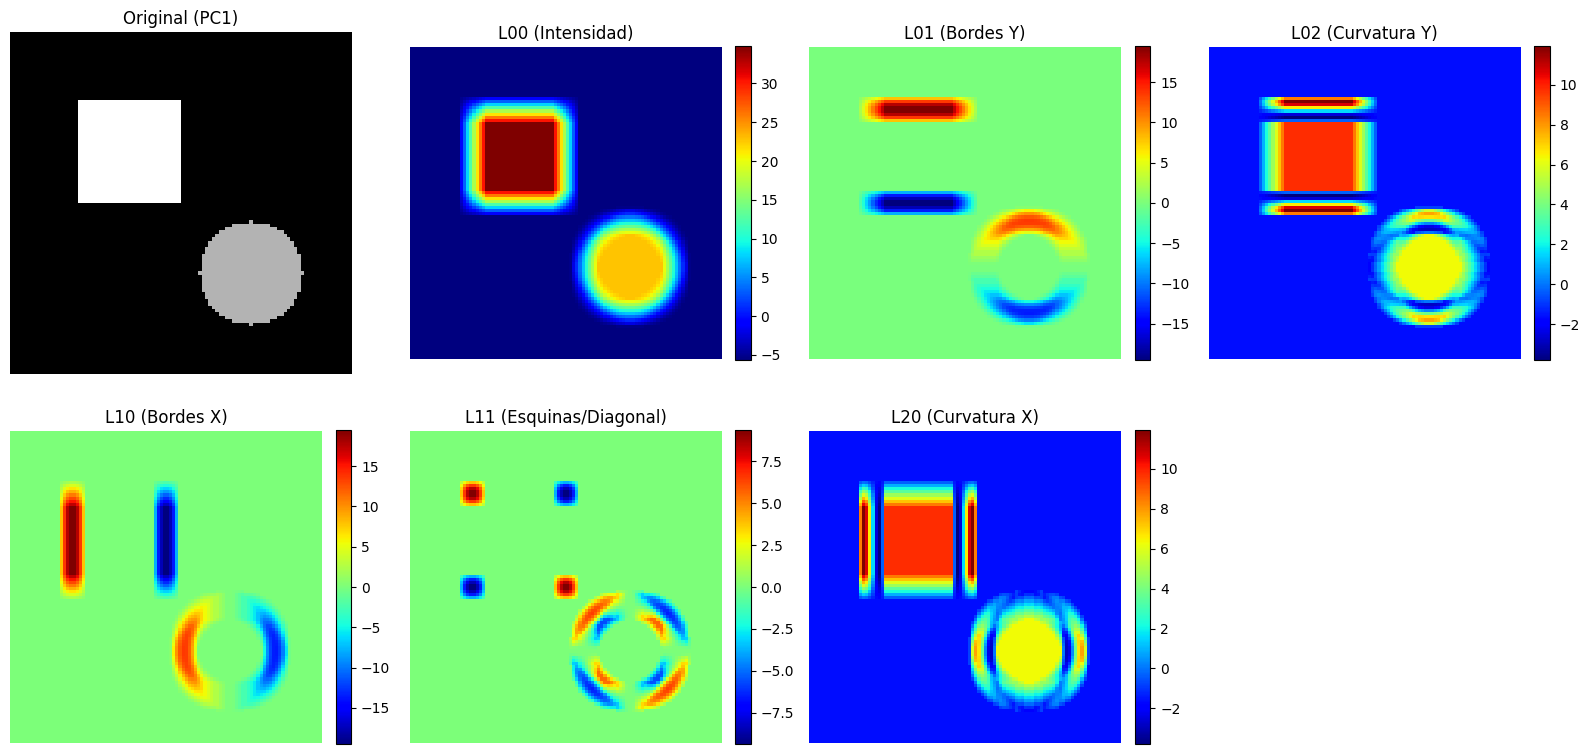

In [6]:
test_visualize_legendre_moments()

### zernike

In [2]:
import hyppo
from hyppo.core import FeatureSpace
from hyppo.extractor import ZernikeMomentExtractor, GeometricMomentExtractor, LegendreMomentExtractor

# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    GeometricMomentExtractor(),
    LegendreMomentExtractor(),
    ZernikeMomentExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
results.describe()

,feature_name,dimensions,extra_data
0,geometric_moment,"(500, 500, 252)","explained_variance_ratio, n_components, window..."
1,legendre_moment,"(500, 500, 252)","explained_variance_ratio, n_components, window..."
2,zernike_moment,"(500, 500, 144)","explained_variance_ratio, n_components, window..."


In [3]:
# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    GeometricMomentExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
results.describe()

,feature_name,dimensions,extra_data
0,geometric_moment,"(500, 500, 252)","explained_variance_ratio, n_components, window..."


In [4]:
# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    LegendreMomentExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
results.describe()

,feature_name,dimensions,extra_data
0,legendre_moment,"(500, 500, 252)","explained_variance_ratio, n_components, window..."


In [6]:
# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    ZernikeMomentExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
results.describe()

,feature_name,dimensions,extra_data
0,zernike_moment,"(500, 500, 144)","explained_variance_ratio, n_components, window..."


In [7]:
import pytest
import numpy as np
from hyppo.core import HSI

def test_zernike_moment_extractor_dimensions():
    """Verifica que las dimensiones de salida de Zernike sean correctas."""
    n_bands = 10
    data = np.random.rand(20, 20, n_bands).astype(np.float32)
    wavelengths = np.linspace(400, 700, n_bands) 
    hsi = HSI(reflectance=data, wavelengths=wavelengths)
    
    n_pcs = 1
    degree = 2
    windows = [9]
    
    # Para degree=2 con q >= 0, las duplas (p,q) válidas son:
    # (0,0), (1,1), (2,0), (2,2) -> 4 momentos
    expected_moments_per_scale = 4 
    total_expected_features = n_pcs * len(windows) * expected_moments_per_scale
    
    extractor = ZernikeMomentExtractor(
        n_components=n_pcs, 
        max_order=degree, 
        window_sizes=windows
    )
    
    result = extractor.extract(hsi)
    features = result["features"]
    
    assert features.shape == (20, 20, total_expected_features)
    print(f"Test pasado. Características: {features.shape[-1]}")

def test_zernike_invalid_params():
    """Valida que Zernike rechace grados negativos."""
    data = np.random.rand(10, 10, 3).astype(np.float32)
    hsi = HSI(reflectance=data, wavelengths=np.arange(3))
    with pytest.raises(ValueError):
        ZernikeMomentExtractor(max_order=-1).extract(hsi)

In [8]:
test_zernike_invalid_params()
test_zernike_moment_extractor_dimensions()

Test pasado. Características: 4


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def test_visualize_zernike_moments():
    # 1. Imagen con cuadrado y círculo
    img = np.zeros((100, 100))
    img[20:50, 20:50] = 1.0
    yy, xx = np.ogrid[:100, :100]
    mask = (xx - 70)**2 + (yy - 70)**2 <= 15**2
    img[mask] = 0.7
    
    data = img[:, :, np.newaxis].astype(np.float32)
    wavelengths = np.array([1.0], dtype=np.float32)
    hsi = HSI(reflectance=data, wavelengths=wavelengths)
    
    # 2. Extraer Zernike de grado 2
    extractor = ZernikeMomentExtractor(n_components=1, degree=2, window_sizes=[9])
    result = extractor.extract(hsi)
    features = result["features"] 
    
    # Nombres de las magnitudes de los momentos
    titles = ["|Z_00| (Intensidad)", "|Z_11| (Desplazamiento)", 
              "|Z_20| (Enfoque Radial)", "|Z_22| (Simetría Cuadripolar)"]
    
    # 3. Visualización
    plt.figure(figsize=(14, 8))
    plt.subplot(2, 3, 1)
    plt.title("Original (PC1)")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    for i in range(min(features.shape[-1], len(titles))):
        plt.subplot(2, 3, i + 2)
        plt.title(titles[i])
        plt.imshow(features[:, :, i], cmap='jet')
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

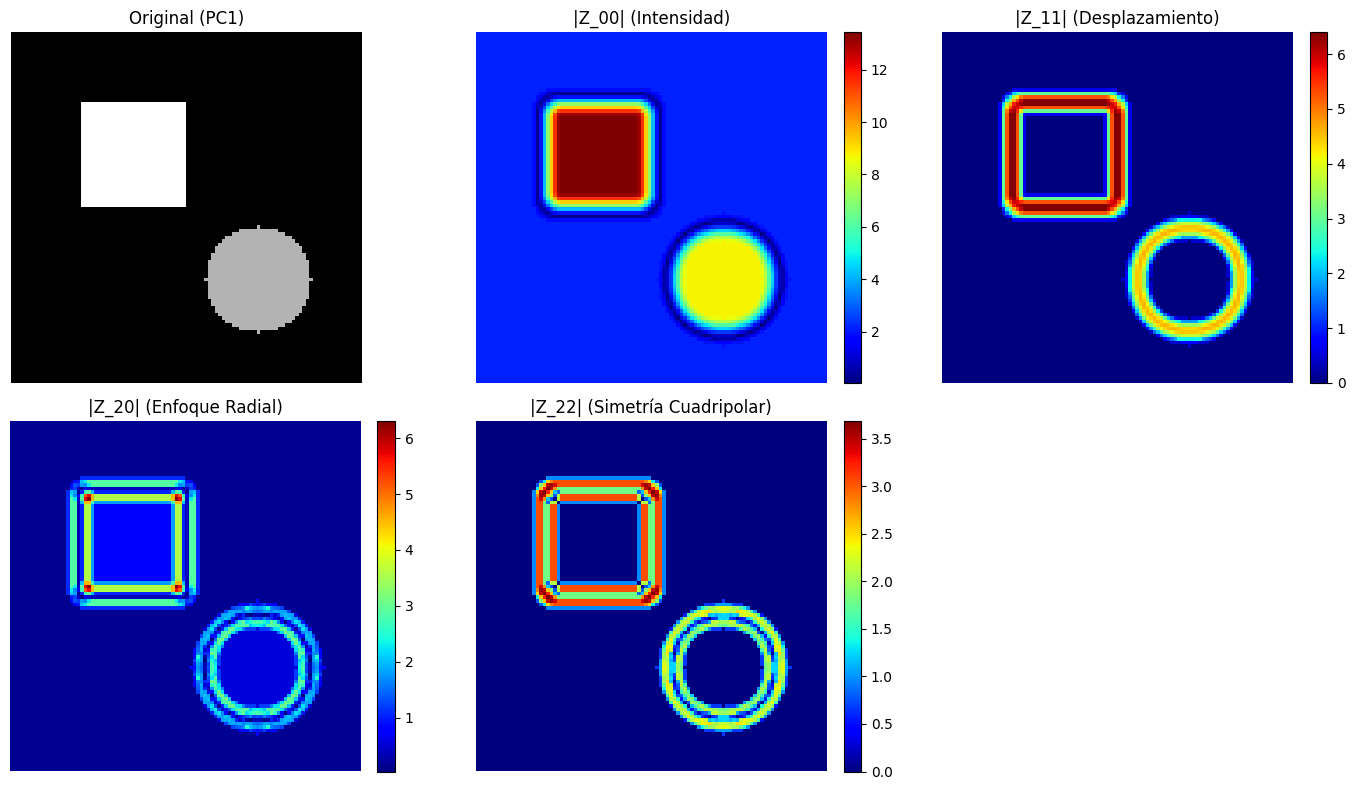

In [5]:
test_visualize_zernike_moments()

### indices

🔵 TEST NDVI: Física y Selección de Bandas...
   Shape Output: (10, 10, 1)
   Shape Output: (10, 10)
   Bandas usadas: Rojo=655nm (Idx 2), NIR=860nm (Idx 4)
✅ Selección de bandas correcta (encontró las más cercanas).
   NDVI Vegetación (Promedio): 0.78 (Esperado > 0.6)
   NDVI Suelo (Promedio): 0.08 (Esperado ~0.1)
✅ Física correcta: Vegetación alta, suelo bajo.


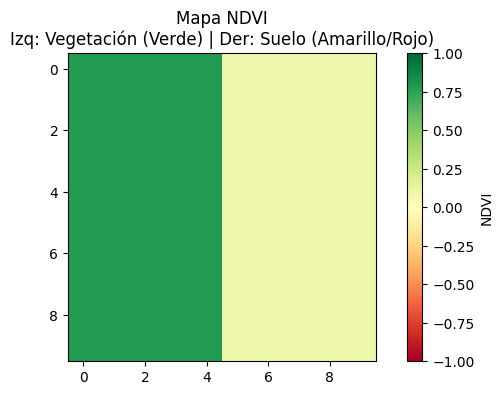

In [3]:
import hyppo
import numpy as np
import matplotlib.pyplot as plt
from hyppo.extractor import NDVIExtractor

# --- MOCK HSI ---
class HSI_Mock:
    def __init__(self, reflectance, wavelengths):
        self.reflectance = reflectance
        self.wavelengths = np.array(wavelengths)

def test_ndvi_physics_and_selection():
    print("🔵 TEST NDVI: Física y Selección de Bandas...")
    
    # 1. Configuración de Bandas
    # Simulamos un sensor que NO tiene exactamente 660nm ni 850nm
    # Tiene 655nm (Red) y 860nm (NIR) -> El código debe seleccionarlas igual.
    wavelengths = [450, 550, 655, 720, 860, 950]
    
    # Índices esperados:
    # 660nm -> más cercano es 655 (índice 2)
    # 850nm -> más cercano es 860 (índice 4)
    expected_red_idx = 2
    expected_nir_idx = 4
    
    # 2. Creación de Imagen Sintética (H=10, W=10)
    H, W = 10, 10
    n_bands = len(wavelengths)
    cube = np.zeros((H, W, n_bands))
    
    # --- ZONA 1 (Izquierda): VEGETACIÓN SANA ---
    # Baja reflectancia en Rojo (absorción clorofila)
    # Alta reflectancia en NIR (estructura celular)
    cube[:, :5, expected_red_idx] = 0.1
    cube[:, :5, expected_nir_idx] = 0.8
    
    # --- ZONA 2 (Derecha): SUELO / TIERRA ---
    # Reflectancia moderada/alta en Rojo
    # Reflectancia similar o ligeramente mayor en NIR (pendiente suave)
    cube[:, 5:, expected_red_idx] = 0.3
    cube[:, 5:, expected_nir_idx] = 0.35  # Poca diferencia
    
    hsi = HSI_Mock(cube, wavelengths)
    
    # 3. Ejecución (Instanciamos buscando los estándares 660 y 850)
    # Nota: Instancia tu clase real aquí
    extractor = NDVIExtractor(red_wavelength=660, nir_wavelength=850)
    result = extractor.extract(hsi)
    
    ndvi_map = result['features']
    print(f"   Shape Output: {ndvi_map.shape}")
    
    # Si aplicaste mi sugerencia de (H, W, 1), quitamos la dim extra para plotear
    if ndvi_map.ndim == 3:
        ndvi_map = ndvi_map[:, :, 0]
        
    print(f"   Shape Output: {ndvi_map.shape}")
    print(f"   Bandas usadas: Rojo={result['wavelength_used'][0]}nm (Idx {result['red_idx']}), "
          f"NIR={result['wavelength_used'][1]}nm (Idx {result['nir_idx']})")

    # --- VERIFICACIONES AUTOMÁTICAS ---
    
    # Check de índices
    if result['red_idx'] == expected_red_idx and result['nir_idx'] == expected_nir_idx:
        print("✅ Selección de bandas correcta (encontró las más cercanas).")
    else:
        print("❌ FALLO en selección de bandas.")

    # Check de valores NDVI
    mean_veg = np.mean(ndvi_map[:, :5])
    mean_soil = np.mean(ndvi_map[:, 5:])
    
    print(f"   NDVI Vegetación (Promedio): {mean_veg:.2f} (Esperado > 0.6)")
    print(f"   NDVI Suelo (Promedio): {mean_soil:.2f} (Esperado ~0.1)")
    
    if mean_veg > 0.6 and mean_soil < 0.2:
        print("✅ Física correcta: Vegetación alta, suelo bajo.")
    else:
        print("❌ FALLO: Los valores NDVI no tienen sentido físico.")

    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(8, 4))
    plt.imshow(ndvi_map, cmap='RdYlGn', vmin=-1, vmax=1)
    plt.colorbar(label="NDVI")
    plt.title(f"Mapa NDVI\nIzq: Vegetación (Verde) | Der: Suelo (Amarillo/Rojo)")
    plt.show()

# Asumiendo que NDVIExtractor está disponible
test_ndvi_physics_and_selection()

🔵 TEST NDWI (McFeeters): Detección de Agua...
   Shape Output: (10, 10)
   NDWI Agua (Promedio): 0.78 (Esperado > 0)
   NDWI Tierra (Promedio): -0.71 (Esperado < 0)
✅ Física correcta: El agua se separa de la tierra.


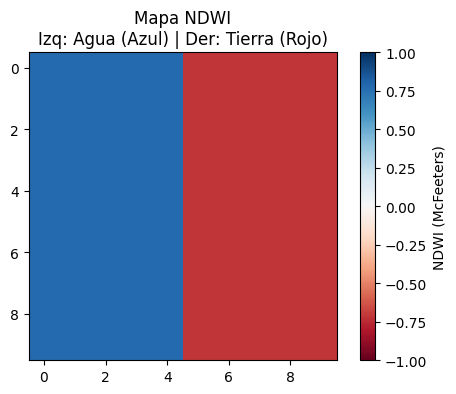

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from hyppo.extractor import NDWIExtractor

# --- MOCK HSI ---
class HSI_Mock:
    def __init__(self, reflectance, wavelengths):
        self.reflectance = reflectance
        self.wavelengths = np.array(wavelengths)

def test_ndwi_physics():
    print("🔵 TEST NDWI (McFeeters): Detección de Agua...")
    
    # 1. Configuración de Bandas
    # Simulamos un sensor con bandas visibles y NIR
    wavelengths = [450, 560, 650, 850, 900]
    expected_green_idx = 1 # 560nm
    expected_nir_idx = 3   # 850nm
    
    H, W = 10, 10
    cube = np.zeros((H, W, len(wavelengths)))
    
    # --- ZONA 1 (Izquierda): AGUA (Lago/Río) ---
    # El agua tiene reflectancia visible moderada (verde/azul) y absorbe NIR fuertemente.
    # Green > NIR -> NDWI Positivo
    cube[:, :5, expected_green_idx] = 0.4
    cube[:, :5, expected_nir_idx]   = 0.05 
    
    # --- ZONA 2 (Derecha): VEGETACIÓN/TIERRA ---
    # La vegetación refleja poco verde y mucho NIR.
    # Green < NIR -> NDWI Negativo
    cube[:, 5:, expected_green_idx] = 0.1
    cube[:, 5:, expected_nir_idx]   = 0.6
    
    hsi = HSI_Mock(cube, wavelengths)
    
    # 2. Ejecución
    # Usamos NDWIExtractor (asegúrate de importar tu clase real)
    extractor = NDWIExtractor(green_wavelength=560, nir_wavelength=850)
    result = extractor.extract(hsi)
    ndwi_map = result['features']
    
    # Si aplicaste el fix de dimensión (H,W,1), aplanamos para graficar
    if ndwi_map.ndim == 3:
        ndwi_map = ndwi_map[:, :, 0]
        
    print(f"   Shape Output: {ndwi_map.shape}")

    # --- VALIDACIÓN FÍSICA ---
    mean_water = np.mean(ndwi_map[:, :5])
    mean_land = np.mean(ndwi_map[:, 5:])
    
    print(f"   NDWI Agua (Promedio): {mean_water:.2f} (Esperado > 0)")
    print(f"   NDWI Tierra (Promedio): {mean_land:.2f} (Esperado < 0)")
    
    # El umbral típico para separar agua es 0, aunque a veces se ajusta.
    if mean_water > 0.5 and mean_land < -0.5:
        print("✅ Física correcta: El agua se separa de la tierra.")
    else:
        print("❌ FALLO: Los valores no discriminan agua de tierra.")
        
    # --- VISUALIZACIÓN ---
    # Usamos colormap 'RdBu' (Rojo-Azul) donde Azul es positivo (Agua)
    plt.figure(figsize=(6, 4))
    plt.imshow(ndwi_map, cmap='RdBu', vmin=-1, vmax=1)
    plt.colorbar(label="NDWI (McFeeters)")
    plt.title(f"Mapa NDWI\nIzq: Agua (Azul) | Der: Tierra (Rojo)")
    plt.show()

test_ndwi_physics()

🔵 TEST SAVI: Estabilidad con Suelo Brillante...
--- Resultados (Misma cobertura vegetal: 40.0%) ---
NDVI (Suelo Oscuro):    0.535
NDVI (Suelo Brillante): 0.371
 >> Caída por suelo:    0.163 (Muy sensible al fondo)

SAVI (Suelo Oscuro):    0.371
SAVI (Suelo Brillante): 0.325
 >> Caída por suelo:    0.046 (Más estable)

✅ ÉXITO: SAVI corrigió el efecto del brillo del suelo mejor que NDVI.


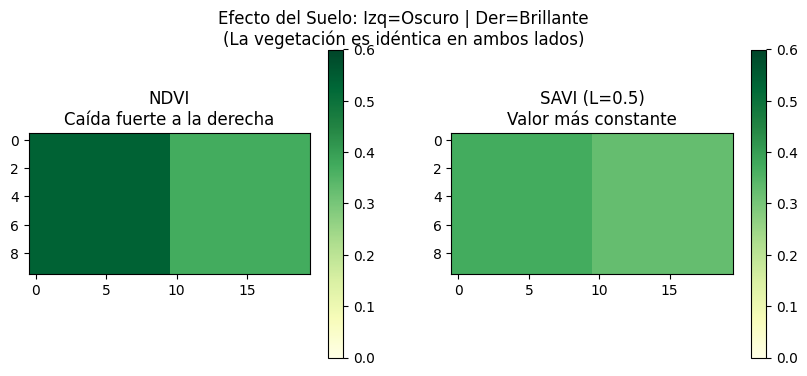

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hyppo.extractor import SAVIExtractor

# --- MOCK HSI ---
class HSI_Mock:
    def __init__(self, reflectance, wavelengths):
        self.reflectance = reflectance
        self.wavelengths = np.array(wavelengths)

def test_savi_vs_ndvi_stability():
    print("🔵 TEST SAVI: Estabilidad con Suelo Brillante...")

    # Configuración de Bandas
    wavelengths = [660, 850] # Red, NIR
    
    H, W = 10, 20
    cube = np.zeros((H, W, 2))
    
    # --- SIMULACIÓN DE REFLECTANCIA (Modelo Lineal de Mezcla) ---
    # Vegetación Pura: Absorbe Rojo (0.1), Refleja NIR (0.6)
    veg_pure = np.array([0.1, 0.6])
    
    # Suelo Oscuro (Húmedo): Baja reflectancia general
    soil_dark = np.array([0.1, 0.15])
    
    # Suelo Brillante (Seco/Arena): Alta reflectancia general
    soil_bright = np.array([0.3, 0.4]) 
    
    # Cobertura vegetal: 40% (Vegetación dispersa -> Caso ideal para SAVI)
    alpha = 0.4 
    
    # ZONA 1 (Izq): 40% Veg + 60% Suelo OSCURO
    mix_dark = alpha * veg_pure + (1 - alpha) * soil_dark
    cube[:, :10, :] = mix_dark
    
    # ZONA 2 (Der): 40% Veg + 60% Suelo BRILLANTE
    mix_bright = alpha * veg_pure + (1 - alpha) * soil_bright
    cube[:, 10:, :] = mix_bright
    
    hsi = HSI_Mock(cube, wavelengths)
    
    # --- EJECUCIÓN ---
    # Calculamos SAVI (L=0.5)
    # Nota: Usa tu clase SAVIExtractor real
    savi_ext = SAVIExtractor(red_wavelength=660, nir_wavelength=850, L=0.5)
    res_savi = savi_ext.extract(hsi)
    feat_savi = res_savi['features'][:, :, 0] # Quitamos dim extra para plot
    
    # Calculamos NDVI (L=0 implícito) manualmente para comparar
    red = cube[:, :, 0]
    nir = cube[:, :, 1]
    feat_ndvi = (nir - red) / (nir + red)
    
    # --- ANÁLISIS ---
    # La vegetación es LA MISMA (40%). El índice ideal no debería cambiar 
    # solo porque el suelo de fondo cambió.
    
    print(f"--- Resultados (Misma cobertura vegetal: {alpha*100}%) ---")
    
    # NDVI
    ndvi_dark = np.mean(feat_ndvi[:, :10])
    ndvi_bright = np.mean(feat_ndvi[:, 10:])
    ndvi_drop = ndvi_dark - ndvi_bright
    print(f"NDVI (Suelo Oscuro):    {ndvi_dark:.3f}")
    print(f"NDVI (Suelo Brillante): {ndvi_bright:.3f}")
    print(f" >> Caída por suelo:    {ndvi_drop:.3f} (Muy sensible al fondo)")
    
    # SAVI
    savi_dark = np.mean(feat_savi[:, :10])
    savi_bright = np.mean(feat_savi[:, 10:])
    savi_drop = savi_dark - savi_bright
    print(f"\nSAVI (Suelo Oscuro):    {savi_dark:.3f}")
    print(f"SAVI (Suelo Brillante): {savi_bright:.3f}")
    print(f" >> Caída por suelo:    {savi_drop:.3f} (Más estable)")

    # Validación
    if savi_drop < ndvi_drop:
        print("\n✅ ÉXITO: SAVI corrigió el efecto del brillo del suelo mejor que NDVI.")
    else:
        print("\n❌ FALLO: SAVI no mejoró la estabilidad.")

    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    im1 = axes[0].imshow(feat_ndvi, vmin=0, vmax=0.6, cmap='YlGn')
    axes[0].set_title(f"NDVI\nCaída fuerte a la derecha")
    plt.colorbar(im1, ax=axes[0])
    
    im2 = axes[1].imshow(feat_savi, vmin=0, vmax=0.6, cmap='YlGn')
    axes[1].set_title(f"SAVI (L=0.5)\nValor más constante")
    plt.colorbar(im2, ax=axes[1])
    
    plt.suptitle(f"Efecto del Suelo: Izq=Oscuro | Der=Brillante\n(La vegetación es idéntica en ambos lados)")
    plt.show()

test_savi_vs_ndvi_stability()

### dwt3d


In [4]:
import hyppo
from hyppo.core import FeatureSpace
from hyppo.extractor import DWT3DExtractor

# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    DWT3DExtractor(),
])

# Extract features
results = fs.extract(hsi)

🔵 TEST 1: Robustez de Dimensiones (Padding 3D)...
   Input Shape: (33, 45, 7)
   Output Shape: (33, 45, 56)
✅ ÉXITO: El extractor manejó el padding y devolvió el tamaño correcto.

🔵 TEST 2: Discriminación Espacial vs. Espectral...


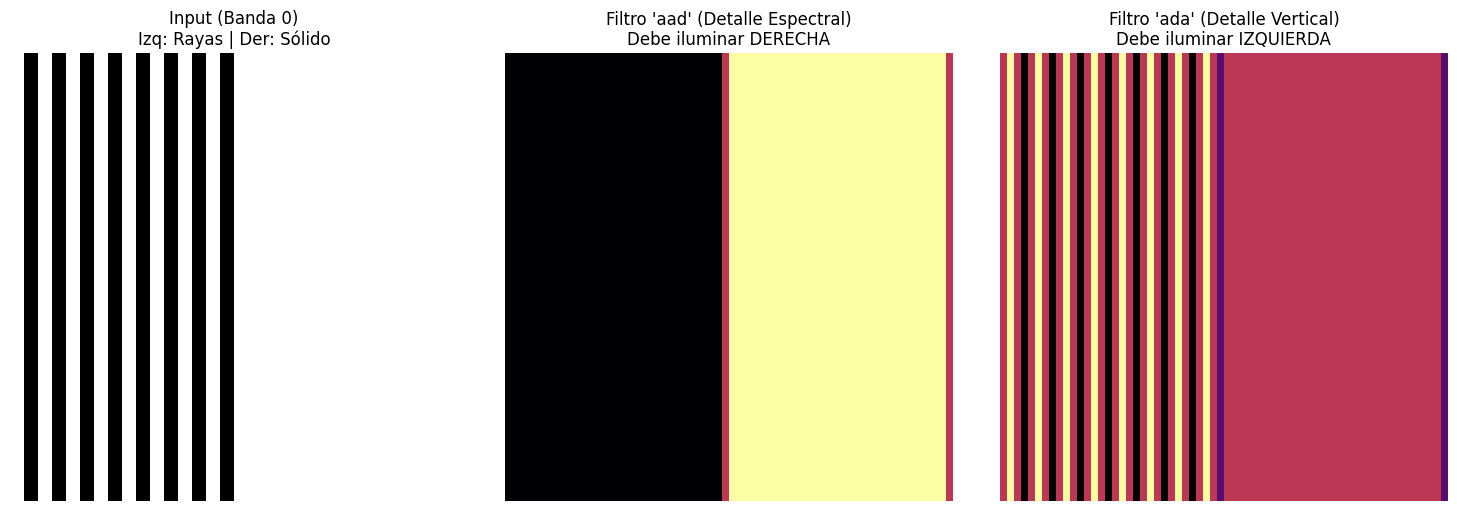

In [5]:
import hyppo
from hyppo.core import FeatureSpace
from hyppo.extractor import DWT3DExtractor

import numpy as np
import matplotlib.pyplot as plt
import pywt

# --- 1. Mocks de Clases (Para que corra independiente) ---
class HSI:
    def __init__(self, reflectance):
        self.reflectance = reflectance

def test_dwt3d_robustness():
    print("🔵 TEST 1: Robustez de Dimensiones (Padding 3D)...")
    
    # Dimensiones impares y raras para romper el algoritmo si el padding falla
    h, w, b = 33, 45, 7 
    print(f"   Input Shape: ({h}, {w}, {b})")
    
    data = np.random.rand(h, w, b)
    hsi = HSI(data)

    extractor = DWT3DExtractor(wavelet='haar', levels=1)
    result = extractor.extract(hsi)
    feats = result['features']

    # Verificación
    # Nivel 1 genera 8 subbandas (aaa, aad, ada, etc.)
    # Como NO diezmamos (SWT), mantenemos H y W.
    # Tu código concatena en el eje espectral: B original * 8 subbandas.
    expected_channels = b * 8 
    
    print(f"   Output Shape: {feats.shape}")
    
    if feats.shape == (h, w, expected_channels):
        print("✅ ÉXITO: El extractor manejó el padding y devolvió el tamaño correcto.")
    else:
        print(f"❌ FALLO: Se esperaba profundidad {expected_channels}, se obtuvo {feats.shape[2]}")

def test_dwt3d_physics():
    print("\n🔵 TEST 2: Discriminación Espacial vs. Espectral...")
    
    # Crear un cubo sintético de 64x64 con 8 bandas
    S, B = 64, 8
    cube = np.zeros((S, S, B))
    
    # --- ZONA 1 (Izquierda): Textura Espacial Pura ---
    # Rayas verticales que son IDÉNTICAS en todas las bandas.
    # Esto debería activar 'daa' (Detail-Approx-Approx) -> Detalle Vertical
    # Pero NO debería activar 'aad' (Approx-Approx-Detail) -> Detalle Espectral
    for i in range(0, 32, 4):
        cube[:, i:i+2, :] = 1.0  # Rayas verticales
        
    # --- ZONA 2 (Derecha): "Textura" Espectral Pura ---
    # Un bloque sólido que parpadea (0 -> 1 -> 0) a través de las bandas.
    # No tiene bordes espaciales internos, solo cambio en Z.
    # Esto debería activar 'aad' (Detalle Espectral).
    for b_idx in range(B):
        if b_idx % 2 == 0:
            cube[:, 32:, b_idx] = 1.0
        else:
            cube[:, 32:, b_idx] = 0.0

    hsi = HSI(cube)
    extractor = DWT3DExtractor(wavelet='haar', levels=1)
    result = extractor.extract(hsi)
    feats = result['features']
    
    # --- VISUALIZACIÓN ---
    # PyWavelets ordena las llaves alfabéticamente:
    # 0: aaa (Aproximación total)
    # 1: aad (Approx espacial, Detalle espectral) <-- Buscamos esto
    # ...
    # 4: daa (Detalle Vertical, Approx otros) <-- Buscamos esto
    
    # Tu código concatena: [Bandas_aaa, Bandas_aad, ..., Bandas_ddd]
    # Queremos ver la banda central (idx 4) de cada tipo de filtro
    mid_band = B // 2
    
    # Indices en el array concatenado
    idx_aad = (1 * B) + mid_band  # Canal de detalle espectral
    idx_ada = (2 * B) + mid_band  # Canal de detalle vertical (espacial)

    feat_aad = feats[:, :, idx_aad]
    feat_ada = feats[:, :, idx_ada]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Original (Banda 0)
    axes[0].imshow(cube[:, :, 0], cmap='gray')
    axes[0].set_title("Input (Banda 0)\nIzq: Rayas | Der: Sólido")
    
    # 2. Detalle Espectral (aad)
    axes[1].imshow(feat_aad, cmap='inferno')
    axes[1].set_title("Filtro 'aad' (Detalle Espectral)\nDebe iluminar DERECHA")
    
    # 3. Detalle Vertical (daa)
    axes[2].imshow(feat_ada, cmap='inferno')
    axes[2].set_title("Filtro 'ada' (Detalle Vertical)\nDebe iluminar IZQUIERDA")
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- EJECUTAR ---
test_dwt3d_robustness()
test_dwt3d_physics()


🔵 TEST 3D: Escalera de Frecuencias (1px vs 2px vs 4px)...
   Output Shape: (64, 96, 24)


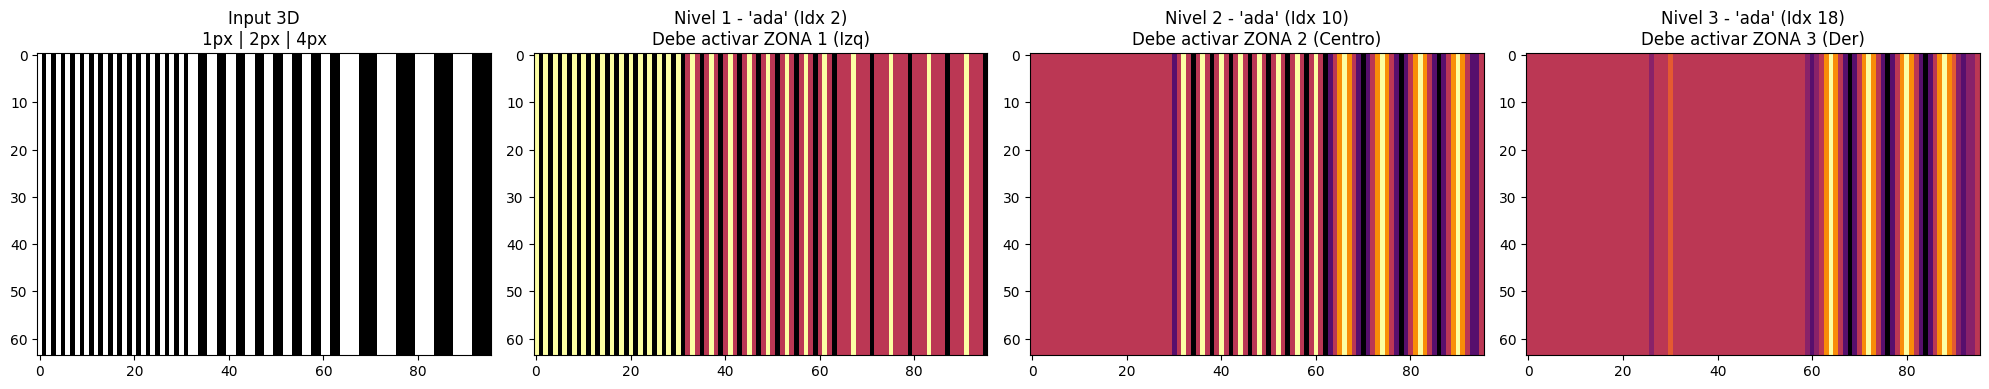

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from hyppo.core import HSI
from hyppo.extractor import DWT3DExtractor

# --- MOCK HSI (Si no lo tienes importado) ---
class HSI_Mock:
    def __init__(self, reflectance, wavelengths=None):
        self.reflectance = reflectance
        if wavelengths is None:
            self.wavelengths = np.arange(reflectance.shape[2])
        else:
            self.wavelengths = wavelengths

def test_dwt3d_multilevel_ladder():
    print("\n🔵 TEST 3D: Escalera de Frecuencias (1px vs 2px vs 4px)...")
    
    # Configuración: 96 ancho para 3 zonas
    H, W = 64, 96
    B = 1  # Usamos 1 banda para simplificar, la lógica 3D aplica igual
    levels = 3
    
    cube = np.zeros((H, W, B))
    
    # --- TEXTURAS (Misma lógica que 2D) ---
    # ZONA 1 (Izq): 1px (Nivel 1)
    for col in range(0, 32, 2):
        cube[:, col, 0] = 1.0
        
    # ZONA 2 (Centro): 2px (Nivel 2)
    for col in range(32, 64, 4):
        cube[:, col:col+2, 0] = 1.0

    # ZONA 3 (Der): 4px (Nivel 3)
    for col in range(64, 96, 8):
        cube[:, col:col+4, 0] = 1.0

    # Instancia
    # IMPORTANTE: Asegúrate de que tu DWT3DExtractor tenga 'reversed(coeffs)' 
    # si quieres el orden Fino -> Grueso.
    hsi = HSI_Mock(cube)
    extractor = DWT3DExtractor(wavelet='haar', levels=levels)
    result = extractor.extract(hsi)
    feats = result['features']
    
    print(f"   Output Shape: {feats.shape}")
    # Esperado: (64, 96, 1 * 8 * 3) = (64, 96, 24)
    
    # --- CÁLCULO DE ÍNDICES 3D ---
    # Estructura: [Nivel 1 (8 subbandas), Nivel 2 (8 subbandas), Nivel 3 (8 subbandas)]
    # Cada subbanda tiene 'B' canales.
    # Las llaves ordenadas de pywt son:
    # 0:aaa, 1:aad, 2:ada, 3:add, 4:daa, 5:dad, 6:dda, 7:ddd
    
    # Buscamos 'ada' (Index 2) -> Detecta Bordes Verticales
    subband_idx = 2 
    
    # Stride (paso) por nivel = 8 subbandas * B canales
    level_stride = 8 * B
    # Stride por subbanda = B canales
    subband_stride = B
    
    # Función auxiliar para buscar el canal exacto
    def get_channel(level_0_based, subband_key_idx):
        # Base del nivel
        idx = level_0_based * level_stride
        # + Base de la subbanda
        idx += subband_key_idx * subband_stride
        # + Banda 0 (ya que B=1)
        return idx

    idx_L1 = get_channel(0, subband_idx) # Nivel 1, 'ada'
    idx_L2 = get_channel(1, subband_idx) # Nivel 2, 'ada'
    idx_L3 = get_channel(2, subband_idx) # Nivel 3, 'ada'
    
    feat_L1 = feats[:, :, idx_L1]
    feat_L2 = feats[:, :, idx_L2]
    feat_L3 = feats[:, :, idx_L3]

    # --- GRAFICAR ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # 1. Original
    axes[0].imshow(cube[:, :, 0], cmap='gray', interpolation='nearest')
    axes[0].set_title("Input 3D\n1px | 2px | 4px")
    
    # 2. Nivel 1
    axes[1].imshow(feat_L1, cmap='inferno')
    axes[1].set_title(f"Nivel 1 - 'ada' (Idx {idx_L1})\nDebe activar ZONA 1 (Izq)")
    
    # 3. Nivel 2
    axes[2].imshow(feat_L2, cmap='inferno')
    axes[2].set_title(f"Nivel 2 - 'ada' (Idx {idx_L2})\nDebe activar ZONA 2 (Centro)")
    
    # 4. Nivel 3
    axes[3].imshow(feat_L3, cmap='inferno')
    axes[3].set_title(f"Nivel 3 - 'ada' (Idx {idx_L3})\nDebe activar ZONA 3 (Der)")
    
    plt.tight_layout()
    plt.show()

# Ejecutar
test_dwt3d_multilevel_ladder()

### 2d varios levels


In [12]:
def test_dwt2d_physics():
    print("\n🔵 TEST 2D: Discriminación Espacial...")
    
    # Mismo cubo sintético
    S, B = 64, 8
    cube = np.zeros((S, S, B))
    
    # ZONA 1: Rayas Verticales (Textura Espacial)
    for i in range(0, 32, 4):
        cube[:, i:i+2, :] = 1.0
        
    # ZONA 2: Parpadeo (Textura Espectral)
    for b_idx in range(B):
        if b_idx % 2 == 0:
            cube[:, 32:, b_idx] = 1.0

    hsi = HSI(cube)
    # Instanciamos la 2D
    extractor = DWT2DExtractor(wavelet='haar', levels=1)
    result = extractor.extract(hsi)
    feats = result['features']
    
    # --- INDICES ---
    # Tu código 2D concatena [cA, cH, cV, cD] por cada banda.
    # Queremos ver la Banda 0 (donde hay rayas y bloque encendido).
    
    # Canal 0: LL (Aproximación) - Debería verse igual a la imagen original
    # Canal 1: LH (Horizontal Detail) -> Detecta BORDES VERTICALES
    # Canal 2: HL (Vertical Detail)   -> Detecta BORDES HORIZONTALES
    
    feat_approx = feats[:, :, 0] 
    feat_vert_edges = feats[:, :, 1] # LH
    feat_horiz_edges = feats[:, :, 2] # HL

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Aproximación (LL)
    axes[0].imshow(feat_approx, cmap='gray')
    axes[0].set_title("ca")
    
    # 2. Detalle Horizontal (LH) - DEBE DETECTAR RAYAS
    axes[1].imshow(feat_vert_edges, cmap='inferno')
    axes[1].set_title("ch")
    
    # 3. Detalle Vertical (HL) - DEBE ESTAR NEGRO
    axes[2].imshow(feat_horiz_edges, cmap='inferno')
    axes[2].set_title("cl")
    
    # NOTA: No hay filtro que detecte el parpadeo de la derecha como textura.
    # La zona derecha aparecerá plana en todos los canales de detalle.
    
    plt.tight_layout()
    plt.show()

# Ejecutar test
test_dwt2d_physics()


🔵 TEST 2D: Discriminación Espacial...


TypeError: HSI.__init__() missing 1 required positional argument: 'wavelengths'


🔵 TEST 2D: Discriminación Espacial...


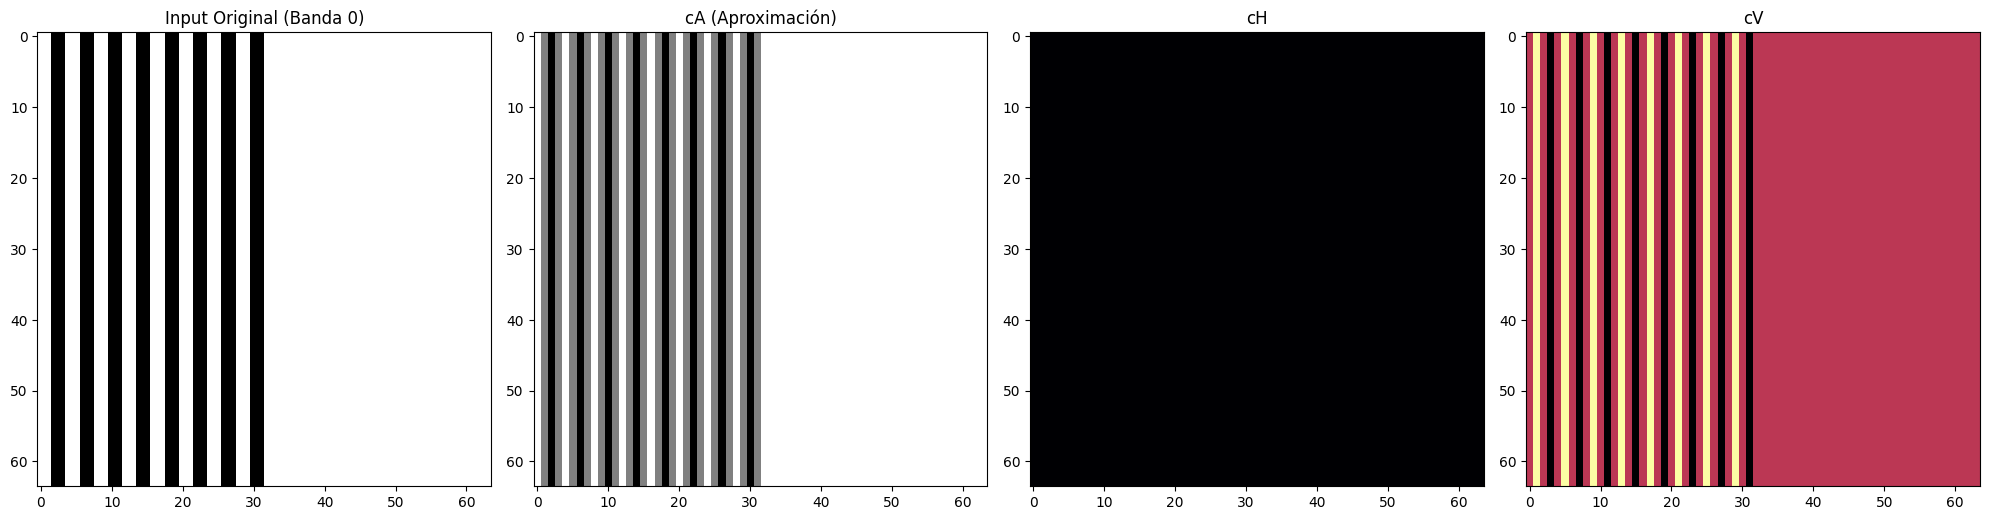

In [7]:
def test_dwt2d_physics():
    print("\n🔵 TEST 2D: Discriminación Espacial...")
    
    # Mismo cubo sintético
    S, B = 64, 8
    cube = np.zeros((S, S, B))
    
    # ZONA 1: Rayas Verticales (Textura Espacial)
    for i in range(0, 32, 4):
        cube[:, i:i+2, :] = 1.0
        
    # ZONA 2: Parpadeo (Textura Espectral)
    for b_idx in range(B):
        if b_idx % 2 == 0:
            cube[:, 32:, b_idx] = 1.0

    hsi = HSI(cube)
    # Instanciamos la 2D
    extractor = DWT2DExtractor(wavelet='haar', levels=1)
    result = extractor.extract(hsi)
    feats = result['features']
    
    # --- INDICES ---
    feat_approx = feats[:, :, 0]      # cA
    feat_vert_edges = feats[:, :, 1]  # cH (Index 1: Detecta cambios horizontales -> Rayas Verticales)
    feat_horiz_edges = feats[:, :, 2] # cV (Index 2: Detecta cambios verticales -> Rayas Horizontales)

    # CAMBIO: 1 fila, 4 columnas (antes eran 3)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # 1. IMAGEN ORIGINAL (Banda 0)
    axes[0].imshow(cube[:, :, 0], cmap='gray')
    axes[0].set_title("Input Original (Banda 0)")
    
    # 2. Aproximación (cA)
    # Debería verse muy similar a la original (versión suavizada)
    axes[1].imshow(feat_approx, cmap='gray')
    axes[1].set_title("cA (Aproximación)")
    
    # 3. Detalle CH (Rayas Verticales)
    axes[2].imshow(feat_vert_edges, cmap='inferno')
    axes[2].set_title("cH")
    
    # 4. Detalle CV (Rayas Horizontales)
    axes[3].imshow(feat_horiz_edges, cmap='inferno')
    axes[3].set_title("cV")
    
    plt.tight_layout()
    plt.show()

# Ejecutar test
test_dwt2d_physics()


🔵 TEST 2D: Multi-Nivel (Frecuencia Fina vs Gruesa)...
Shape de features: (64, 64, 8)


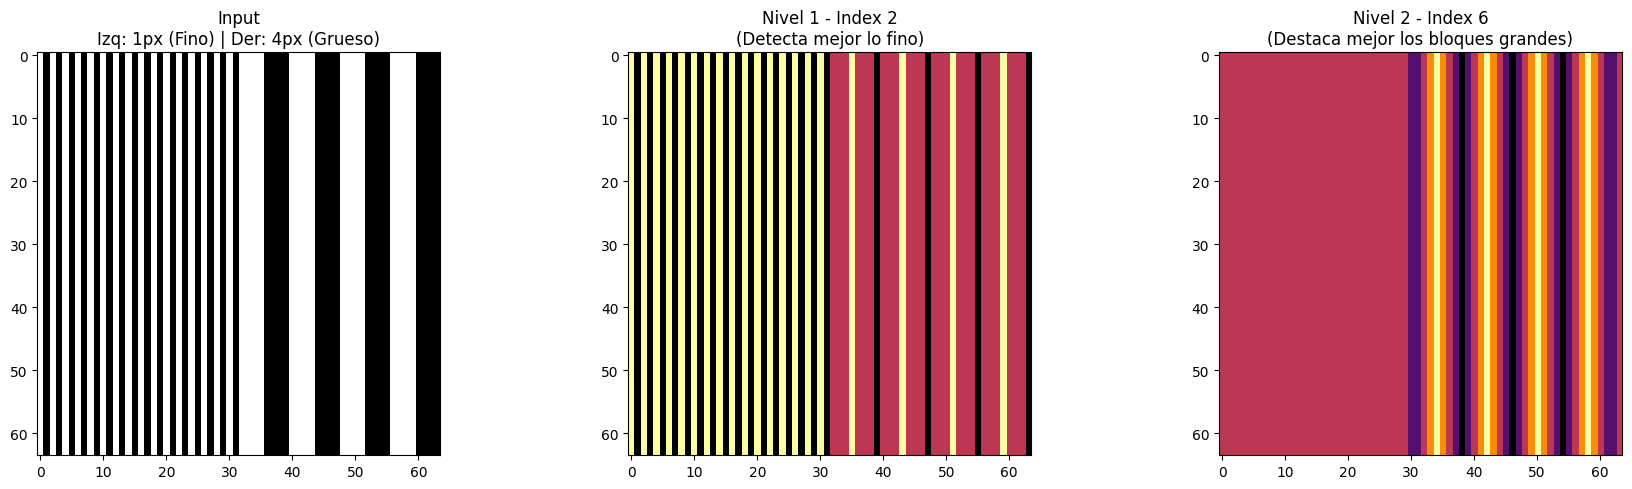

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import hyppo
from hyppo.core import HSI
from hyppo.extractor import DWT2DExtractor

def test_dwt2d_multilevel():
    print("\n🔵 TEST 2D: Multi-Nivel (Frecuencia Fina vs Gruesa)...")
    
    # Configuración
    S = 64
    B = 1  
    levels = 2
    
    cube = np.zeros((S, S, B))
    
    # --- CREACIÓN DE TEXTURAS ---
    
    # ZONA 1 (Izquierda): Rayas FINAS (1 px ancho)
    # Patrón 101010... (Alta frecuencia espacial)
    for col in range(0, 32, 2):
        cube[:, col, 0] = 1.0
        
    # ZONA 2 (Derecha): Rayas GRUESAS (4 px ancho)
    # Patrón 11110000... (Frecuencia espacial media/baja)
    for col in range(32, 64, 8):
        cube[:, col:col+4, 0] = 1.0

    # --- CORRECCIÓN AQUÍ ---
    # La clase HSI real necesita wavelengths. Creamos unos ficticios.
    dummy_wavelengths = np.linspace(400, 2500, B) 
    hsi = HSI(cube, dummy_wavelengths)
    
    # Instanciamos con levels=2
    extractor = DWT2DExtractor(wavelet='haar', levels=levels)
    result = extractor.extract(hsi)
    feats = result['features']
    
    print(f"Shape de features: {feats.shape}")
    # Esperado: (64, 64, 8) -> 1 banda * 2 niveles * 4 subbandas

    # --- EXTRACCIÓN DE CANALES ESPECÍFICOS ---
    # Tu estructura empírica para 'haar' fue:
    # Index 2: Rayas Verticales (cV)
    
    # NIVEL 1 (Indices 0-3)
    # El detalle vertical está en el offset 2
    idx_L1 = 2
    feat_L1_vert = feats[:, :, idx_L1]
    
    # NIVEL 2 (Indices 4-7)
    # El detalle vertical está en el offset 4 (del nivel anterior) + 2 = 6
    idx_L2 = 4 + 2
    feat_L2_vert = feats[:, :, idx_L2]

    # --- GRAFICAR ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Original
    axes[0].imshow(cube[:, :, 0], cmap='gray', interpolation='nearest')
    axes[0].set_title(f"Input\nIzq: 1px (Fino) | Der: 4px (Grueso)")
    
    # 2. Nivel 1 (Detalle Fino)
    axes[1].imshow(feat_L1_vert, cmap='inferno')
    axes[1].set_title(f"Nivel 1 - Index {idx_L1}\n(Detecta mejor lo fino)")
    
    # 3. Nivel 2 (Detalle Grueso)
    axes[2].imshow(feat_L2_vert, cmap='inferno')
    axes[2].set_title(f"Nivel 2 - Index {idx_L2}\n(Destaca mejor los bloques grandes)")
    
    plt.tight_layout()
    plt.show()

test_dwt2d_multilevel()


🔵 TEST 2D: Escala Perfecta (1px vs 2px vs 4px)...


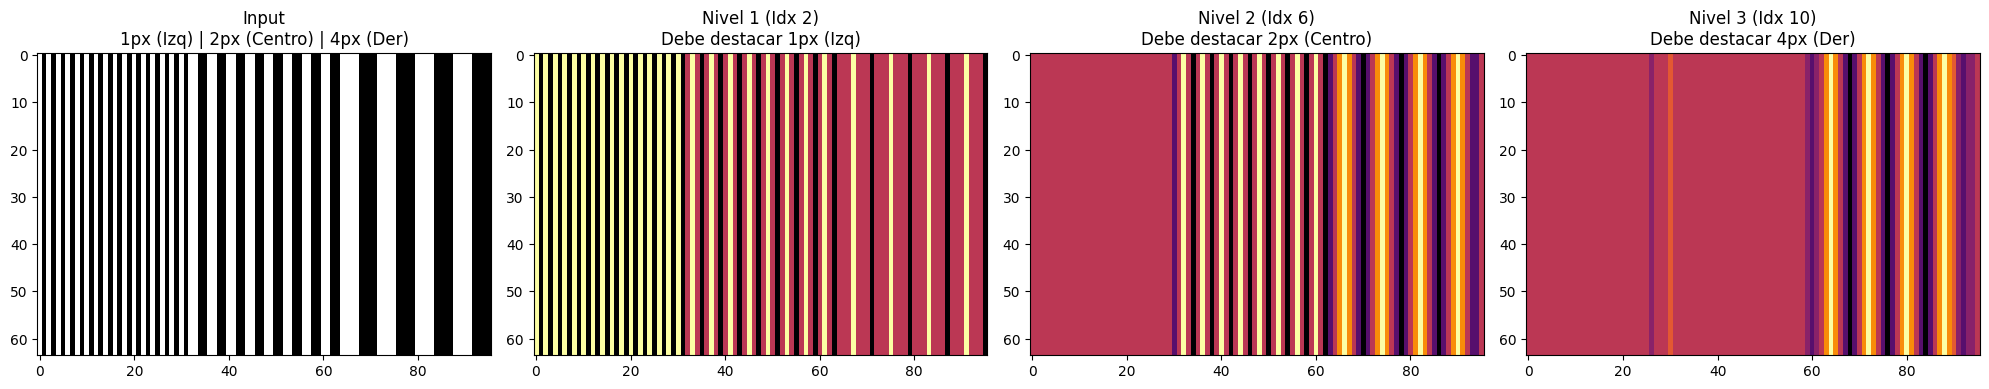

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def test_dwt2d_3levels():
    print("\n🔵 TEST 2D: Escala Perfecta (1px vs 2px vs 4px)...")
    
    # Configuración
    H, W = 64, 96 
    B = 1
    levels = 3
    
    cube = np.zeros((H, W, B))
    
    # --- CREACIÓN DE TEXTURAS (Potencias de 2 exactas) ---
    
    # ZONA 1 (0-32): Ancho 1px (Periodo 2px: 1 blanco, 1 negro)
    # Target: Nivel 1
    for col in range(0, 32, 2):
        cube[:, col, 0] = 1.0
        
    # ZONA 2 (32-64): Ancho 2px (Periodo 4px: 2 blancos, 2 negros)
    # Target: Nivel 2
    for col in range(32, 64, 4):
        cube[:, col:col+2, 0] = 1.0

    # ZONA 3 (64-96): Ancho 4px (Periodo 8px: 4 blancos, 4 negros)
    # Target: Nivel 3
    for col in range(64, 96, 8):
        cube[:, col:col+4, 0] = 1.0

    # Instanciamos
    hsi = HSI(cube, np.linspace(400, 1000, B))
    extractor = DWT2DExtractor(wavelet='haar', levels=levels)
    result = extractor.extract(hsi)
    feats = result['features']
    
    # --- SELECCIÓN DE CANALES (Asumiendo fix 'reversed' aplicado) ---
    # Nivel 1 (Fino):   Offset 0 -> Índice 2
    idx_L1 = 2
    # Nivel 2 (Medio):  Offset 4 -> Índice 6
    idx_L2 = 4 + 2
    # Nivel 3 (Grueso): Offset 8 -> Índice 10
    idx_L3 = 8 + 2
    
    feat_L1 = feats[:, :, idx_L1]
    feat_L2 = feats[:, :, idx_L2]
    feat_L3 = feats[:, :, idx_L3]

    # --- GRAFICAR ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # 1. Original
    axes[0].imshow(cube[:, :, 0], cmap='gray', interpolation='nearest')
    axes[0].set_title("Input\n1px (Izq) | 2px (Centro) | 4px (Der)")
    
    # 2. Nivel 1
    axes[1].imshow(feat_L1, cmap='inferno')
    axes[1].set_title(f"Nivel 1 (Idx {idx_L1})\nDebe destacar 1px (Izq)")
    
    # 3. Nivel 2
    axes[2].imshow(feat_L2, cmap='inferno')
    axes[2].set_title(f"Nivel 2 (Idx {idx_L2})\nDebe destacar 2px (Centro)")
    
    # 4. Nivel 3
    axes[3].imshow(feat_L3, cmap='inferno')
    axes[3].set_title(f"Nivel 3 (Idx {idx_L3})\nDebe destacar 4px (Der)")
    
    plt.tight_layout()
    plt.show()

test_dwt2d_3levels()

### dwt2d


In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import hyppo
from hyppo.core import FeatureSpace
from hyppo.extractor import DWT2DExtractor

# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    DWT2DExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
print(results.get_all_features())
print(results.describe())

{'features': array([[[ 9.55499932e-02,  2.31499989e-02,  5.54499999e-02, ...,
         -6.15000073e-03,  2.89499965e-02, -9.75000020e-03],
        [ 7.33499974e-02, -8.85000266e-03, -3.32500041e-02, ...,
         -1.45000010e-03,  3.25000007e-03,  5.04999980e-03],
        [ 1.00699998e-01, -2.32999995e-02,  5.90000302e-03, ...,
         -8.54999851e-03, -2.26499997e-02,  2.04999838e-03],
        ...,
        [ 1.05799988e-01,  5.39999921e-03, -4.36999947e-02, ...,
          1.05000054e-03, -4.65000421e-03,  8.95000063e-03],
        [ 1.44449979e-01,  8.55000131e-03,  5.04999608e-03, ...,
          4.70000040e-03,  7.69999996e-03, -1.26000000e-02],
        [ 1.45199984e-01,  2.25000028e-02, -5.80000132e-03, ...,
          6.99999742e-04,  2.50000134e-03,  1.66000016e-02]],

       [[ 1.05199993e-01, -3.27999927e-02,  2.44999975e-02, ...,
         -3.56999971e-02,  1.57000050e-02,  2.29999982e-02],
        [ 1.11249991e-01, -2.90499944e-02, -3.05499956e-02, ...,
         -5.61999939e-02,

Detectado formato Array directo. Shape: (500, 500, 428)


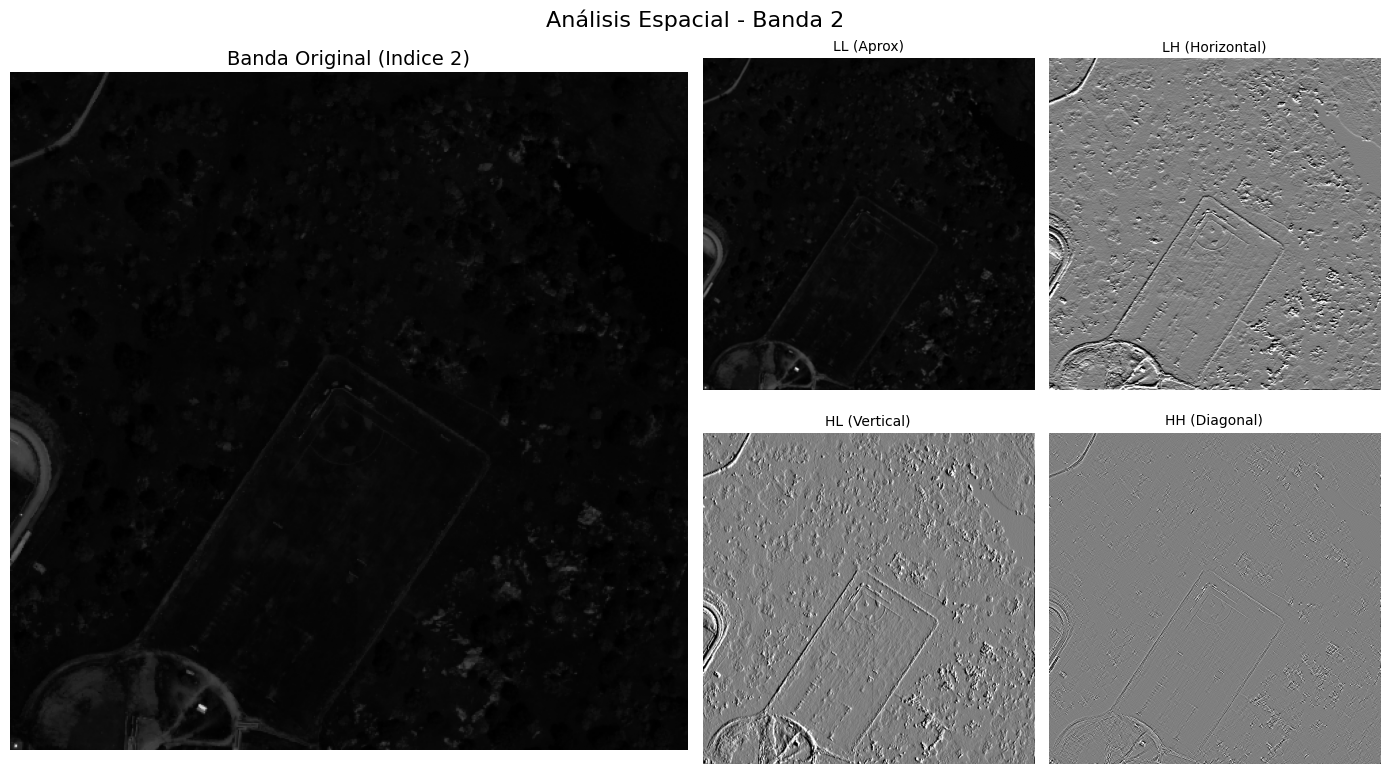

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dwt2d_results(hsi_data, results_object, band_index=0, extractor_name='dwt2d'):
    """
    Grafica la descomposición Wavelet 2D obtenida con DWT2DExtractor.
    Versión robusta que detecta si el resultado es diccionario o array.
    """
    
    features = None
    
    # --- 1. RECUPERACIÓN DE DATOS (Agnóstica a la estructura) ---
    try:
        # A. Obtener el contenedor del FeatureSpace
        if extractor_name in results_object:
            container = results_object[extractor_name]
        else:
            raise KeyError(f"No se encontró '{extractor_name}'. Claves: {list(results_object.keys())}")

        # B. Extraer el contenido crudo (result)
        # Algunos objetos Feature guardan la data en .result, otros en ['result']
        raw_result = getattr(container, 'result', None)
        if raw_result is None and hasattr(container, 'get'):
             raw_result = container.get('result')
        
        if raw_result is None:
            # Caso extremo: el contenedor mismo es la data
            raw_result = container

        # C. Determinar si es Diccionario o Array (La corrección clave)
        if isinstance(raw_result, np.ndarray):
            # Es directamente la matriz (Caso común en tu versión de hyppo)
            features = raw_result
            print(f"Detectado formato Array directo. Shape: {features.shape}")
        elif isinstance(raw_result, dict) and 'features' in raw_result:
            # Es un diccionario preservado
            features = raw_result['features']
            print(f"Detectado formato Diccionario. Shape: {features.shape}")
        else:
            raise ValueError(f"Formato de resultado desconocido: {type(raw_result)}")

    except Exception as e:
        print(f"Error crítico recuperando datos: {e}")
        return

    # --- 2. GRAFICADO ---
    
    # Calcular índices (4 subbandas por cada banda de entrada)
    start_idx = band_index * 4
    
    # Validación de rango
    if start_idx + 3 >= features.shape[2]:
        print(f"Error: La banda {band_index} está fuera del rango de características ({features.shape[2]}).")
        return

    # Extraer componentes: Orden [cA, cH, cV, cD]
    LL = features[:, :, start_idx + 0] 
    LH = features[:, :, start_idx + 1] 
    HL = features[:, :, start_idx + 2] 
    HH = features[:, :, start_idx + 3] 
    
    # Obtener banda original
    original_band = hsi_data.reflectance[:, :, band_index]

    # Configuración de la figura
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 4)
    
    # Panel Izquierdo: Original
    ax_orig = fig.add_subplot(gs[:, :2])
    ax_orig.imshow(original_band, cmap='gray')
    ax_orig.set_title(f"Banda Original (Indice {band_index})", fontsize=14)
    ax_orig.axis('off')
    
    # Panel Derecho: Componentes Wavelet
    # Percentiles para mejor contraste en detalles
    vmin = np.percentile(features[:, :, start_idx+1:start_idx+4], 1)
    vmax = np.percentile(features[:, :, start_idx+1:start_idx+4], 99)

    ax_ll = fig.add_subplot(gs[0, 2])
    ax_ll.imshow(LL, cmap='gray')
    ax_ll.set_title("LL (Aprox)", fontsize=10); ax_ll.axis('off')

    ax_lh = fig.add_subplot(gs[0, 3])
    ax_lh.imshow(LH, cmap='gray', vmin=vmin, vmax=vmax)
    ax_lh.set_title("LH (Horizontal)", fontsize=10); ax_lh.axis('off')

    ax_hl = fig.add_subplot(gs[1, 2])
    ax_hl.imshow(HL, cmap='gray', vmin=vmin, vmax=vmax)
    ax_hl.set_title("HL (Vertical)", fontsize=10); ax_hl.axis('off')

    ax_hh = fig.add_subplot(gs[1, 3])
    ax_hh.imshow(HH, cmap='gray', vmin=vmin, vmax=vmax)
    ax_hh.set_title("HH (Diagonal)", fontsize=10); ax_hh.axis('off')

    plt.suptitle(f"Análisis Espacial - Banda {band_index}", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- EJECUTAR ---
plot_dwt2d_results(hsi, results, band_index=2)

Ejecutando DWT2DExtractor sobre imagen sintética...


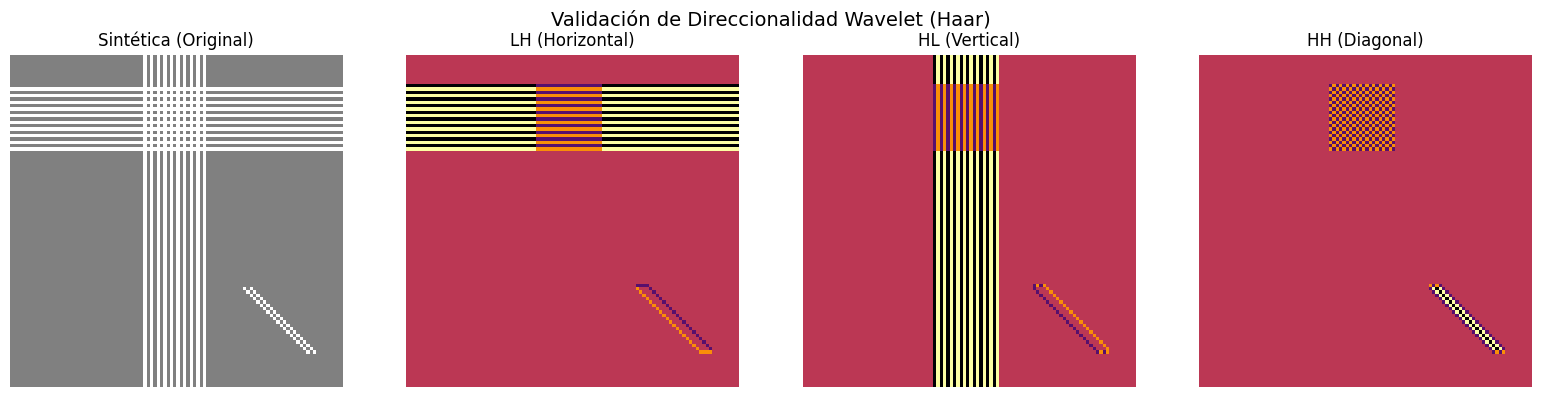

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import hyppo
from hyppo.core import HSI
from hyppo.extractor import DWT2DExtractor

def test_wavelet_directionality():
    # 1. Crear imagen sintética (100x100)
    size = 100
    img = np.zeros((size, size))
    
    # Añadir patrón HORIZONTAL (filas 10-30)
    img[10:30:2, :] = 1 
    
    # Añadir patrón VERTICAL (columnas 40-60)
    img[:, 40:60:2] = 1
    
    # Añadir patrón DIAGONAL (esquina inferior derecha)
    # Dibujamos líneas diagonales paralelas
    for i in range(70, 90):
        img[i, i] = 1
        img[i, i+2] = 1 

    hsi_mock = HSI(
        img[:, :, np.newaxis], 
        wavelengths=np.array([0])  # <--- Cambio: np.array
    ) 
    
    # 2. Ejecutar tu extractor
    print("Ejecutando DWT2DExtractor sobre imagen sintética...")
    extractor = DWT2DExtractor(wavelet='haar', levels=1)
    result = extractor.extract(hsi_mock)
    
    # Manejo robusto de la salida (por si es dict o array)
    if isinstance(result, dict) and 'features' in result:
        features = result['features']
    elif hasattr(result, 'result') and isinstance(result.result, dict):
        features = result.result['features']
    elif hasattr(result, 'result') and isinstance(result.result, np.ndarray):
        features = result.result
    else:
        # Fallback para estructuras anidadas
        try:
            features = result['dwt2d']['result']['features']
        except:
            print("No se pudo desempaquetar 'result'. Estructura:", type(result))
            return

    # 3. Graficar Resultados
    # Índices: 0=LL, 1=LH, 2=HL, 3=HH
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Original
    axes[0].imshow(img, cmap='gray', alpha=0.5)
    axes[0].set_title("Sintética (Original)")
    
    # LH: Debería resaltar SOLO las líneas de arriba (filas 10-30)
    axes[1].imshow(features[:, :, 1], cmap='inferno')
    axes[1].set_title("LH (Horizontal)")
    
    # HL: Debería resaltar SOLO las líneas del medio (cols 40-60)
    axes[2].imshow(features[:, :, 2], cmap='inferno')
    axes[2].set_title("HL (Vertical)")
    
    # HH: Debería resaltar SOLO las líneas de abajo a la derecha
    axes[3].imshow(features[:, :, 3], cmap='inferno')
    axes[3].set_title("HH (Diagonal)")
    
    for ax in axes: ax.axis('off')
    plt.suptitle("Validación de Direccionalidad Wavelet (Haar)", fontsize=14)
    plt.tight_layout()
    plt.show()

# --- EJECUTAR ---
test_wavelet_directionality()

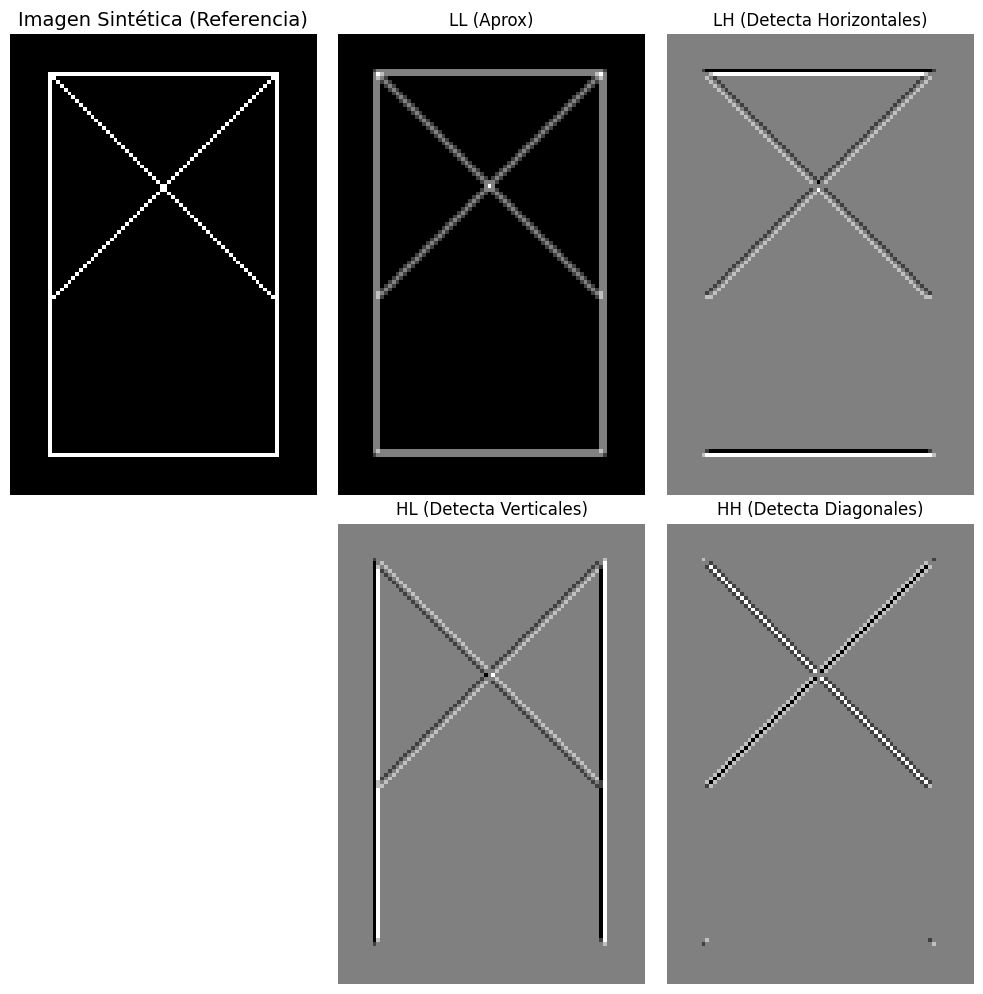

In [4]:
import hyppo
from hyppo.core import HSI
from hyppo.extractor import DWT2DExtractor


import numpy as np
import matplotlib.pyplot as plt
import pywt


def create_reference_pattern():
    """
    Crea una imagen de 200x205 píxeles replicando el patrón de la referencia:
    - Bloque Sup. Izq: Líneas horizontales
    - Bloque Sup. Der: Líneas horizontales
    - Bloque Central: Líneas verticales
    - Bloque Inf. Izq: Vacío (Negro)
    - Bloque Inf. Der: Líneas Diagonales
    """
    H, W = 200, 205
    img = np.zeros((H, W), dtype=np.float32)
    
    # Grosor de línea y espaciado
    thickness = 2
    spacing = 6
    
    # A. ZONA SUPERIOR (Filas 0-70) - Líneas Horizontales
    # Cubre todo el ancho excepto la franja central vertical
    # Izquierda (0-100) y Derecha (145-205)
    for r in range(10, 70, spacing):
        img[r:r+thickness, 0:100] = 1   # Sup. Izq
        img[r:r+thickness, 145:205] = 1 # Sup. Der

    # B. ZONA CENTRAL (Columnas 100-145 y 75-100 abajo) - Líneas Verticales
    # Franja vertical grande en el medio (Arriba)
    for c in range(100, 145, spacing):
        img[0:110, c:c+thickness] = 1
        
    # Franja vertical desplazada (Abajo centro-izq)
    for c in range(75, 100, spacing):
        img[70:200, c:c+thickness] = 1

    # C. ZONA INFERIOR DERECHA (Filas 110-200, Cols 100-205) - Diagonales
    # x + y = const
    for i in range(110, 200):
        for j in range(100, 205):
            if (i + j) % 8 < 2: 
                img[i, j] = 1
                
    # D. ZONA INFERIOR IZQUIERDA (Filas 70-200, Cols 0-75)
    # Se deja en 0 (Negro), como en tu imagen.

    return img

# --- 3. EJECUCIÓN Y VISUALIZACIÓN ---

# Crear datos
image = create_reference_pattern()
hsi_mock = HSI(image[:, :, np.newaxis], wavelengths=np.array([0]))

# Crear imagen sintética (100x60 aprox para lograr proporción parecida)
height, width = 120, 80
img = np.zeros((height, width))

# Coordenadas del rectángulo
x_min, x_max = 10, 70
y_min, y_max = 10, 110

# --- Dibujar bordes del rectángulo ---
img[y_min, x_min:x_max] = 1        # borde superior
img[y_max-1, x_min:x_max] = 1      # borde inferior
img[y_min:y_max, x_min] = 1        # borde izquierdo
img[y_min:y_max, x_max-1] = 1      # borde derecho

# --- Dibujar diagonales ---
for k in range(x_max - x_min):
    y = y_min + k
    x = x_min + k
    if y < y_max and x < x_max:
        img[y, x] = 1                      # diagonal ↘
    if y < y_max and (x_max - k - 1) >= x_min:
        img[y, x_max - k - 1] = 1          # diagonal ↙

# Convertir a HSI (1 banda)
hsi_mock = HSI(
    img[:, :, np.newaxis],
    wavelengths=np.array([0])
)

hsi_mock


# Ejecutar TU extractor
extractor = DWT2DExtractor(wavelet='haar', levels=1)
result = extractor.extract(hsi_mock)
features = result['features']

# Graficar
LL = features[:, :, 0] # Aprox
LH = features[:, :, 1] # Horizontal
HL = features[:, :, 2] # Vertical
HH = features[:, :, 3] # Diagonal

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 3)

# Panel 1: Imagen Original Sintética
ax_orig = fig.add_subplot(gs[0, 0])
ax_orig.imshow(img, cmap='gray')
ax_orig.set_title("Imagen Sintética (Referencia)", fontsize=14)
ax_orig.axis('off')

# Panel 2: LL (Aproximación)
ax_ll = fig.add_subplot(gs[0, 1])
ax_ll.imshow(LL, cmap='gray')
ax_ll.set_title("LL (Aprox)", fontsize=12); ax_ll.axis('off')

# Panel 3: LH (Horizontal) -> Debe activar las zonas A
ax_lh = fig.add_subplot(gs[0, 2])
ax_lh.imshow(LH, cmap='gray')
ax_lh.set_title("LH (Detecta Horizontales)", fontsize=12); ax_lh.axis('off')

# Panel 4: HL (Vertical) -> Debe activar las zonas B
ax_hl = fig.add_subplot(gs[1, 1])
ax_hl.imshow(HL, cmap='gray')
ax_hl.set_title("HL (Detecta Verticales)", fontsize=12); ax_hl.axis('off')

# Panel 5: HH (Diagonal) -> Debe activar la zona C
ax_hh = fig.add_subplot(gs[1, 2])
ax_hh.imshow(HH, cmap='gray')
ax_hh.set_title("HH (Detecta Diagonales)", fontsize=12); ax_hh.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import sys
print(sys.executable)

/home/paulap/Escritorio/PhD/hyppo/bin/python


### dwt1d

In [1]:
import hyppo
from hyppo.core import FeatureSpace
from hyppo.extractor import DWT1DExtractor

# Load hyperspectral image
hsi = hyppo.io.load_h5_hsi("../NEON.h5")

# Create feature space with extractors
fs = FeatureSpace.from_list([
    DWT1DExtractor(),
])

# Extract features
results = fs.extract(hsi)

# Access results
print(results.get_all_features())
print(results.describe())

{'features': array([[[ 1.07261263e-01,  1.02780059e-01,  9.64828283e-02, ...,
         -3.13073816e-03, -4.54633636e-03, -1.28345843e-03],
        [ 4.30108421e-02,  4.15094867e-02,  4.05359492e-02, ...,
         -5.07742539e-03,  3.92336352e-03, -1.43323478e-03],
        [ 5.67246079e-02,  5.51053546e-02,  5.32851666e-02, ...,
         -3.22497077e-03, -4.36320296e-03, -4.31449153e-05],
        ...,
        [ 1.25296250e-01,  1.28145859e-01,  1.26360193e-01, ...,
         -1.28434487e-02, -6.92227762e-03, -1.30911754e-03],
        [ 1.58902511e-01,  1.59725249e-01,  1.53910875e-01, ...,
          1.78778218e-03, -7.48860044e-03, -5.74234000e-04],
        [ 1.56235263e-01,  1.56316757e-01,  1.51020184e-01, ...,
         -3.47567897e-04, -4.99635842e-03,  3.99370212e-04]],

       [[ 1.05446070e-01,  1.05269089e-01,  9.97374058e-02, ...,
         -1.31892078e-02,  1.13088649e-03, -4.09069587e-04],
        [ 4.75887731e-02,  4.82569709e-02,  4.80427667e-02, ...,
          5.88575006e-03,

In [ ]:
results['dwt1d']

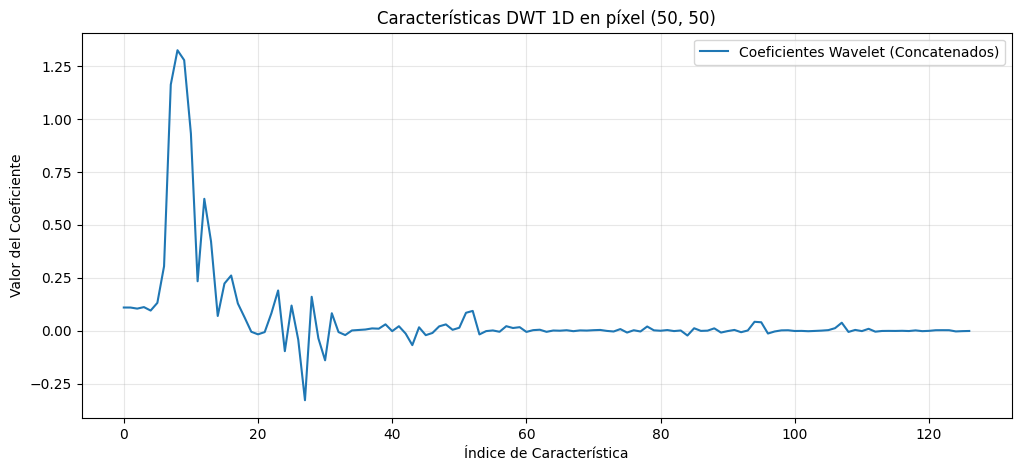

In [4]:
def parse_and_plot_pixel(results_object, feature_name='dwt1d', pixel_x=50, pixel_y=50):
    """
    Versión simplificada: Grafica el vector de características completo sin 
    necesidad de 'coeffs_lengths'.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 1. Recuperar el contenedor de resultados
    if feature_name not in results_object:
        print(f"Error: No se encontró '{feature_name}' en los resultados.")
        return

    container = results_object[feature_name]
    
    # 2. Extraer el cubo de datos (features)
    # Buscamos en .result, ['result'] o el objeto mismo
    if hasattr(container, 'result'):
        data = container.result
    elif isinstance(container, dict) and 'result' in container:
        data = container['result']
    else:
        data = container

    # Extraer el array de features
    # Puede estar directamente en 'data' o dentro de la clave 'features'
    if isinstance(data, dict) and 'features' in data:
        features_cube = data['features']
    elif isinstance(data, np.ndarray):
        features_cube = data
    else:
        print(f"No se pudo encontrar el array de features. Tipo: {type(data)}")
        return

    # 3. Seleccionar el píxel
    # features_cube shape: (H, W, N_Features)
    pixel_signal = features_cube[pixel_y, pixel_x, :]
    
    # 4. Graficar (Simple, un solo color)
    plt.figure(figsize=(12, 5))
    plt.plot(pixel_signal, label='Coeficientes Wavelet (Concatenados)')
    plt.title(f"Características DWT 1D en píxel ({pixel_x}, {pixel_y})")
    plt.xlabel("Índice de Característica")
    plt.ylabel("Valor del Coeficiente")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
parse_and_plot_pixel(results)